# Импорт библиотек и настройка среды

In [113]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportion_confint
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

In [114]:
pd.set_option("display.max_columns", 100)
pd.set_option('display.max_colwidth', None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Удобства для навигации

In [115]:
navigation = dict()

# Загрузка датасета и его краткий осмотр

Загрузка датасета

In [230]:
data = pd.read_csv("../data/raw/cs-training.csv")
data = data.drop(columns=["Unnamed: 0"], errors="ignore")

In [231]:
navigation["переменная датасета"] = "data"

Улучшение наименования столбцов

In [232]:
data = data.rename(columns={
    "SeriousDlqin2yrs": "target",
    "RevolvingUtilizationOfUnsecuredLines": "revolving_utilization",
    "age": "age",
    "NumberOfTime30-59DaysPastDueNotWorse": "num_30_59_days_late",
    "DebtRatio": "debt_ratio",
    "MonthlyIncome": "monthly_income",
    "NumberOfOpenCreditLinesAndLoans": "num_open_credit_lines",
    "NumberOfTimes90DaysLate": "num_90_days_late",
    "NumberRealEstateLoansOrLines": "num_real_estate_loans",
    "NumberOfTime60-89DaysPastDueNotWorse": "num_60_89_days_late",
    "NumberOfDependents": "num_dependents"
})

Формирование описания признаков

In [233]:
data_dictionary = pd.DataFrame({
    "column": data.columns,
    "description": [
        "У человека была просрочка 90 дней и более или более серьёзное нарушение платёжной дисциплины",
        "Общий баланс по кредитным картам и личным кредитным линиям, кроме недвижимости и долгов в рассрочку, например автокредитов, делённый на сумму кредитных лимитов",
        "Возраст заёмщика в годах",
        "Количество раз, когда заёмщик имел просрочку 30–59 дней, но не хуже, за последние 2 года",
        "Ежемесячные выплаты по долгам, алименты и расходы на проживание, делённые на ежемесячный валовый доход",
        "Ежемесячный доход",
        "Количество открытых кредитов, например автокредит или ипотека, и кредитных линий, например кредитных карт",
        "Количество раз, когда заёмщик имел просрочку 90 дней или более",
        "Количество ипотечных и других кредитов, связанных с недвижимостью, включая кредитные линии под залог жилья",
        "Количество раз, когда заёмщик имел просрочку 60–89 дней, но не хуже, за последние 2 года",
        "Количество иждивенцев в семье, не включая самого заёмщика: супруг/супруга, дети и т. д."
    ],
    "types": [
        "binary",
        "percent",
        "integer",
        "count",
        "percent",
        "float",
        "count",
        "count",
        "count",
        "count",
        "count"
    ],
    "role": [
        "target",
        "feature",
        "feature",
        "feature",
        "feature",
        "feature",
        "feature",
        "feature",
        "feature",
        "feature",
        "feature"
    ]
})

In [234]:
navigation["описание признаков"] = "data_dictionary"

Описание признаков

In [235]:
data_dictionary

,column,description,types,role
0,target,У человека была просрочка 90 дней и более или более серьёзное нарушение платёжной дисциплины,binary,target
1,revolving_utilization,"Общий баланс по кредитным картам и личным кредитным линиям, кроме недвижимости и долгов в рассрочку, например автокредитов, делённый на сумму кредитных лимитов",percent,feature
2,age,Возраст заёмщика в годах,integer,feature
3,num_30_59_days_late,"Количество раз, когда заёмщик имел просрочку 30–59 дней, но не хуже, за последние 2 года",count,feature
4,debt_ratio,"Ежемесячные выплаты по долгам, алименты и расходы на проживание, делённые на ежемесячный валовый доход",percent,feature
5,monthly_income,Ежемесячный доход,float,feature
6,num_open_credit_lines,"Количество открытых кредитов, например автокредит или ипотека, и кредитных линий, например кредитных карт",count,feature
7,num_90_days_late,"Количество раз, когда заёмщик имел просрочку 90 дней или более",count,feature
8,num_real_estate_loans,"Количество ипотечных и других кредитов, связанных с недвижимостью, включая кредитные линии под залог жилья",count,feature
9,num_60_89_days_late,"Количество раз, когда заёмщик имел просрочку 60–89 дней, но не хуже, за последние 2 года",count,feature


Размерность датасета

In [236]:
data.shape

(150000, 11)

Столбцы и типы данных датасета

In [237]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   target                 150000 non-null  int64  
 1   revolving_utilization  150000 non-null  float64
 2   age                    150000 non-null  int64  
 3   num_30_59_days_late    150000 non-null  int64  
 4   debt_ratio             150000 non-null  float64
 5   monthly_income         120269 non-null  float64
 6   num_open_credit_lines  150000 non-null  int64  
 7   num_90_days_late       150000 non-null  int64  
 8   num_real_estate_loans  150000 non-null  int64  
 9   num_60_89_days_late    150000 non-null  int64  
 10  num_dependents         146076 non-null  float64
dtypes: float64(4), int64(7)
memory usage: 12.6 MB


Краткий взгляд на данные

In [238]:
data.sample(3)

,target,revolving_utilization,age,num_30_59_days_late,debt_ratio,monthly_income,num_open_credit_lines,num_90_days_late,num_real_estate_loans,num_60_89_days_late,num_dependents
36324,0,0.1675,49,0,0.4477,"5,000.0000",8,0,2,0,1.0000
43950,0,0.3797,45,0,0.2468,"11,115.0000",8,0,1,0,2.0000
25738,0,0.1054,36,0,0.2751,"10,833.0000",3,0,1,0,3.0000


**Вывод по блоку:**
1. данных достаточно много;
2. пропусков в данных не много, что хорошо;
3. типы признаков все числовые, что хорошо, не нужно будет выполнять кодирование категориальных признаков.

# Общая проверка качества данных

Проверка наличия дубликатов

In [239]:
duplicates_summary = (
    data.duplicated()
    .agg(["sum", "mean"])
    .T
    .rename({"sum": "duplicate_count", "mean": "duplicate_percent"})
)
duplicates_summary["duplicate_percent"] = duplicates_summary["duplicate_percent"] * 100

In [240]:
navigation["количество дубликатов в данных"] = "duplicates_summary"

In [241]:
duplicates_summary

duplicate_count     609.0000
duplicate_percent     0.4060
dtype: float64

Сразу удалим полные дубликаты, чтобы они не искажали анализ.

In [242]:
data = data.drop_duplicates(keep="first")

Первичная проверка наличия пропусков

In [243]:
missing_summary = (
    data.isna()
    .agg(["sum", "mean"])
    .T
    .rename(columns={"sum": "missings_count", "mean": "missings_percent"})
)
missing_summary["missings_percent"] = missing_summary["missings_percent"] * 100

In [244]:
navigation["количество пропусков в данных"] = "missing_summary"

In [245]:
missing_summary

,missings_count,missings_percent
target,0.0000,0.0000
revolving_utilization,0.0000,0.0000
age,0.0000,0.0000
num_30_59_days_late,0.0000,0.0000
debt_ratio,0.0000,0.0000
monthly_income,"29,221.0000",19.5601
num_open_credit_lines,0.0000,0.0000
num_90_days_late,0.0000,0.0000
num_real_estate_loans,0.0000,0.0000
num_60_89_days_late,0.0000,0.0000


**Вывод по блоку:**
1. Данные, кажутся, качественными;
2. Дубликаты есть, но их не много, так что их наличие незначительно, нужно будет просто потом их удалить;
3. Пропусков не много, но их количество не позволит их безболезненно удалить, поэтому сначала нужно посмотреть на зависимости между признаками.

# Распределение целевой переменной

Распределение целевой переменной

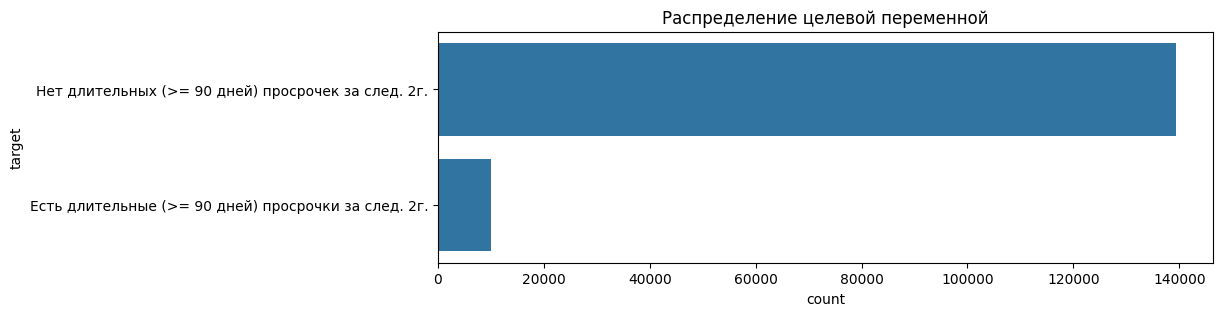

In [246]:
plt.figure(figsize=(10, 3))
sns.countplot(data, y="target")
plt.title("Распределение целевой переменной")
plt.yticks([0, 1], ["Нет длительных (>= 90 дней) просрочек за след. 2г.", "Есть длительные (>= 90 дней) просрочки за след. 2г."], rotation=0)
plt.show()

Соотношение классов

In [247]:
target_class_stats = (
    data["target"]
    .value_counts()
    .rename_axis("target")
    .reset_index(name="count")
)
target_class_stats["percent"] = target_class_stats["count"] / target_class_stats["count"].sum() * 100

In [248]:
navigation["оценка соотношения классов"] = "target_class_stats"

In [249]:
target_class_stats

,target,count,percent
0,0,139382,93.3001
1,1,10009,6.6999


**Вывод по блоку:**
1. Присутствует большой дисбаланс классов;
2. В качестве метрики качества accuracy будет неинформативной, стоит использовать ROC-AUC или PR-ROC.

# Анализ распределений признаков, выбросов и невозможных значений

Анализ числовых характеристик признаков

In [292]:
def make_features_values_analysis(data: pd.DataFrame) -> pd.DataFrame:    
    df_without_target = data.drop(columns="target")
    
    result = (
        df_without_target
        .describe(percentiles=[0.005, 0.01, 0.05, 0.1, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.995])
        .T
    )[["count", "min", "0.5%", "1%", "5%", "10%", "25%", "mean", "std", "50%", "75%", "90%", "95%", "99%", "99.5%", "max"]]

    result["gamma1"] = df_without_target.skew()
    result["gamma2"] = df_without_target.kurtosis()

    return result

In [293]:
navigation["функция для формирования числовых характеристик признаков"] =\
    "make_features_values_analysis(data: pd.DataFrame)"

In [294]:
features_values_analysis = make_features_values_analysis(data=data)

In [295]:
navigation["числовые характеристики признаков"] = "features_values_analysis"

In [296]:
features_values_analysis

,count,min,0.5%,1%,5%,10%,25%,mean,std,50%,75%,90%,95%,99%,99.5%,max,gamma1,gamma2
revolving_utilization,"149,391.0000",0.0000,0.0000,0.0000,0.0000,0.0032,0.0301,6.0711,250.2637,0.1542,0.5565,0.9780,1.0000,1.0939,1.3689,"50,708.0000",97.4332,"14,485.6753"
age,"149,391.0000",0.0000,23.0000,24.0000,29.0000,33.0000,41.0000,52.3062,14.7260,52.0000,63.0000,72.0000,78.0000,87.0000,89.0000,109.0000,0.1923,-0.4940
num_30_59_days_late,"149,391.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.3939,3.8530,0.0000,0.0000,1.0000,2.0000,4.0000,5.0000,98.0000,24.4746,616.2456
debt_ratio,"149,391.0000",0.0000,0.0000,0.0000,0.0052,0.0350,0.1774,354.4367,"2,041.8435",0.3682,0.8753,"1,275.0000","2,455.5000","4,985.1000","6,191.0500","329,664.0000",94.9797,"13,681.5883"
monthly_income,"120,170.0000",0.0000,0.0000,0.0000,"1,300.0000","2,029.0000","3,400.0000","6,675.0983","14,389.5822","5,400.0000","8,250.0000","11,666.0000","14,594.1000","25,000.0000","35,000.0000","3,008,750.0000",114.0166,"19,493.9996"
num_open_credit_lines,"149,391.0000",0.0000,0.0000,0.0000,2.0000,3.0000,5.0000,8.4809,5.1365,8.0000,11.0000,15.0000,18.0000,24.0000,27.0000,58.0000,1.2218,3.1173
num_90_days_late,"149,391.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.2381,3.8262,0.0000,0.0000,0.0000,1.0000,3.0000,4.0000,98.0000,25.1074,637.8524
num_real_estate_loans,"149,391.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0224,1.1302,1.0000,2.0000,2.0000,3.0000,4.0000,6.0000,54.0000,3.4847,60.5859
num_60_89_days_late,"149,391.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.2125,3.8105,0.0000,0.0000,0.0000,1.0000,2.0000,2.0000,98.0000,25.4244,649.0934
num_dependents,"145,563.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.7599,1.1161,0.0000,1.0000,2.0000,3.0000,4.0000,5.0000,20.0000,1.5833,2.9843


Иллюстрация распределений признаков (для несемметричных будем использовать логарифмическое распределение)

In [263]:
discrete_features = [
    "num_30_59_days_late",
    "num_open_credit_lines",
    "num_90_days_late",
    "num_real_estate_loans",
    "num_60_89_days_late",
    "num_dependents"
]
continuous_features = [
    "revolving_utilization",
    "age",
    "debt_ratio",
    "monthly_income"
]

navigation["дискретные признаки"] = "discrete_features"
navigation["непрерывные признаки"] = "continuous_features"

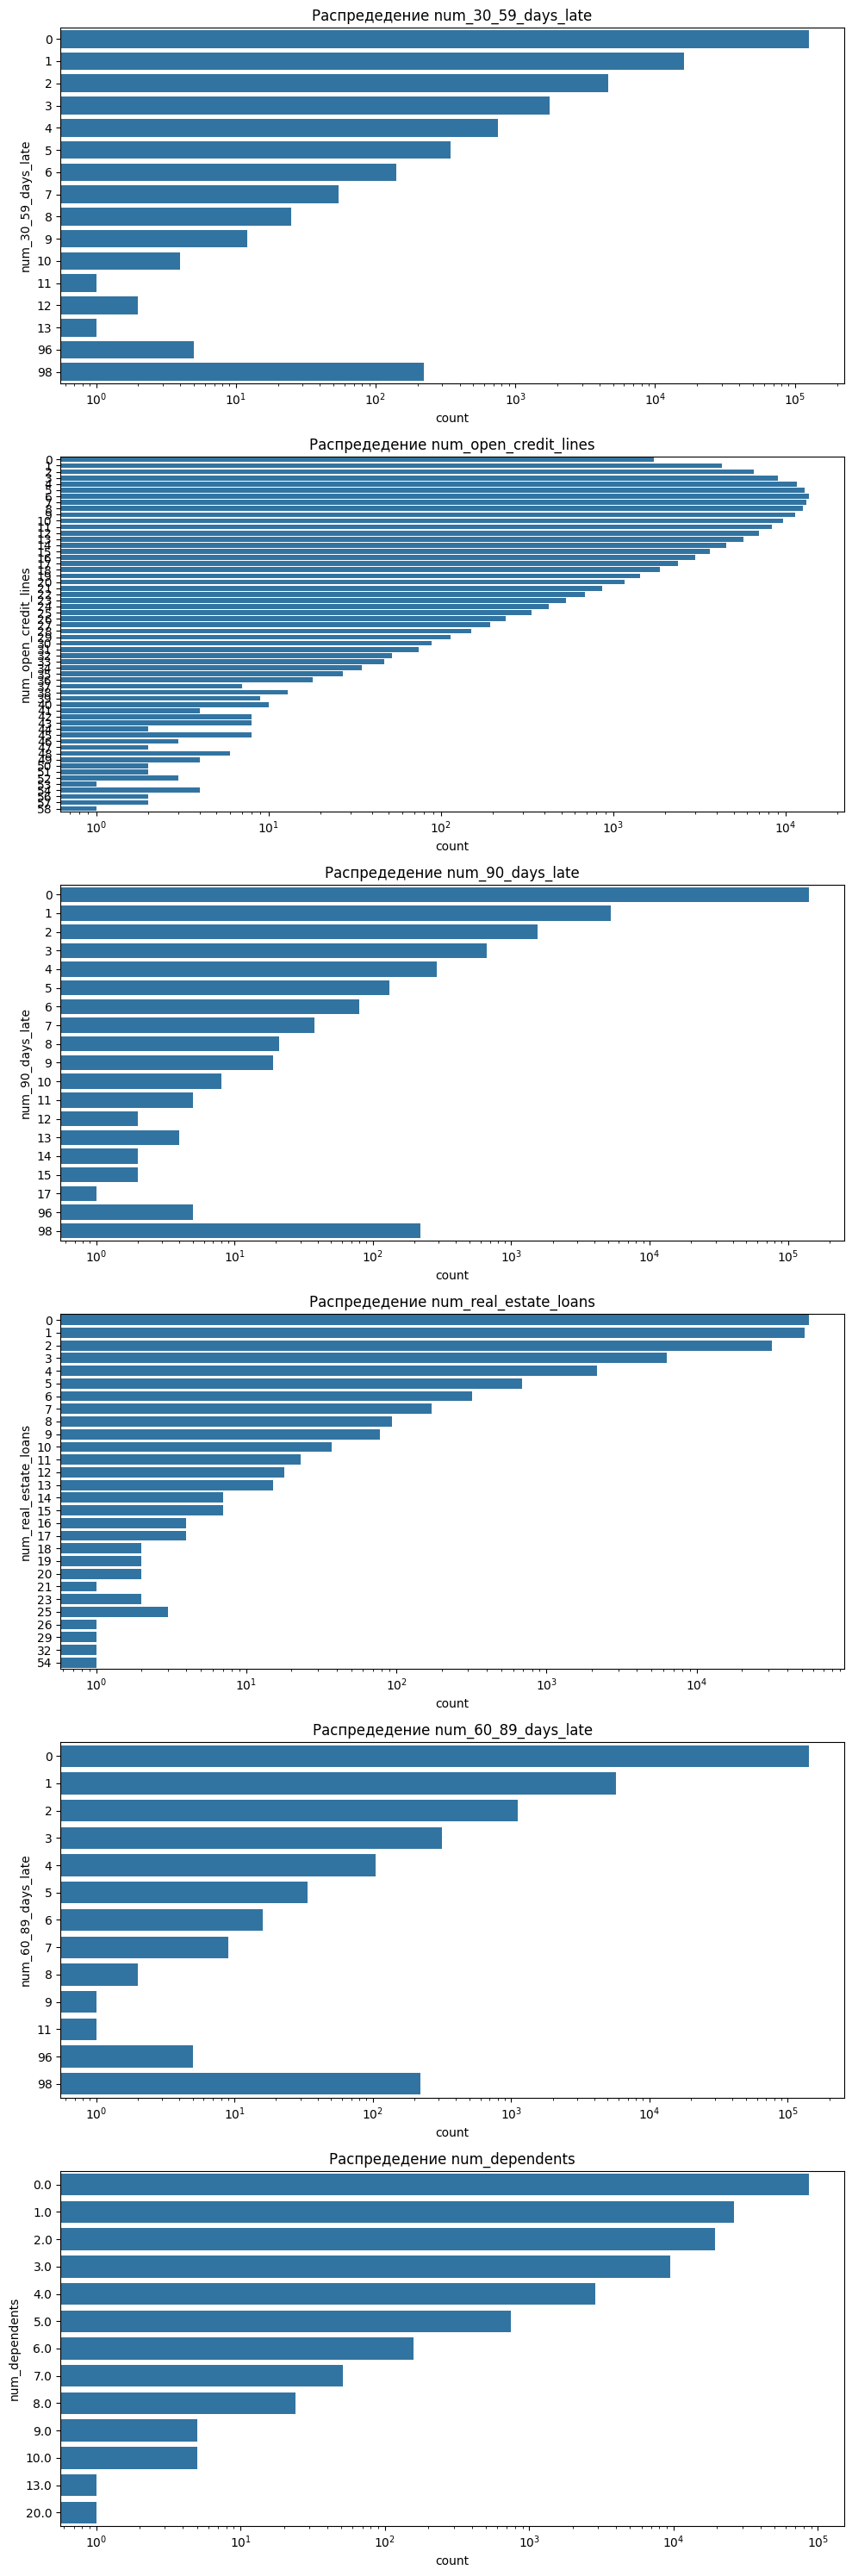

In [279]:
num_descrete_features = len(discrete_features)

plt.figure(figsize=(10, 30))
for i, column in enumerate(discrete_features):
    plt.subplot(num_descrete_features, 1, i + 1)
    sns.countplot(data=data, y=column)
    plt.xscale("log")
    plt.title(f"Распредедение {column}")

plt.tight_layout()
plt.show()

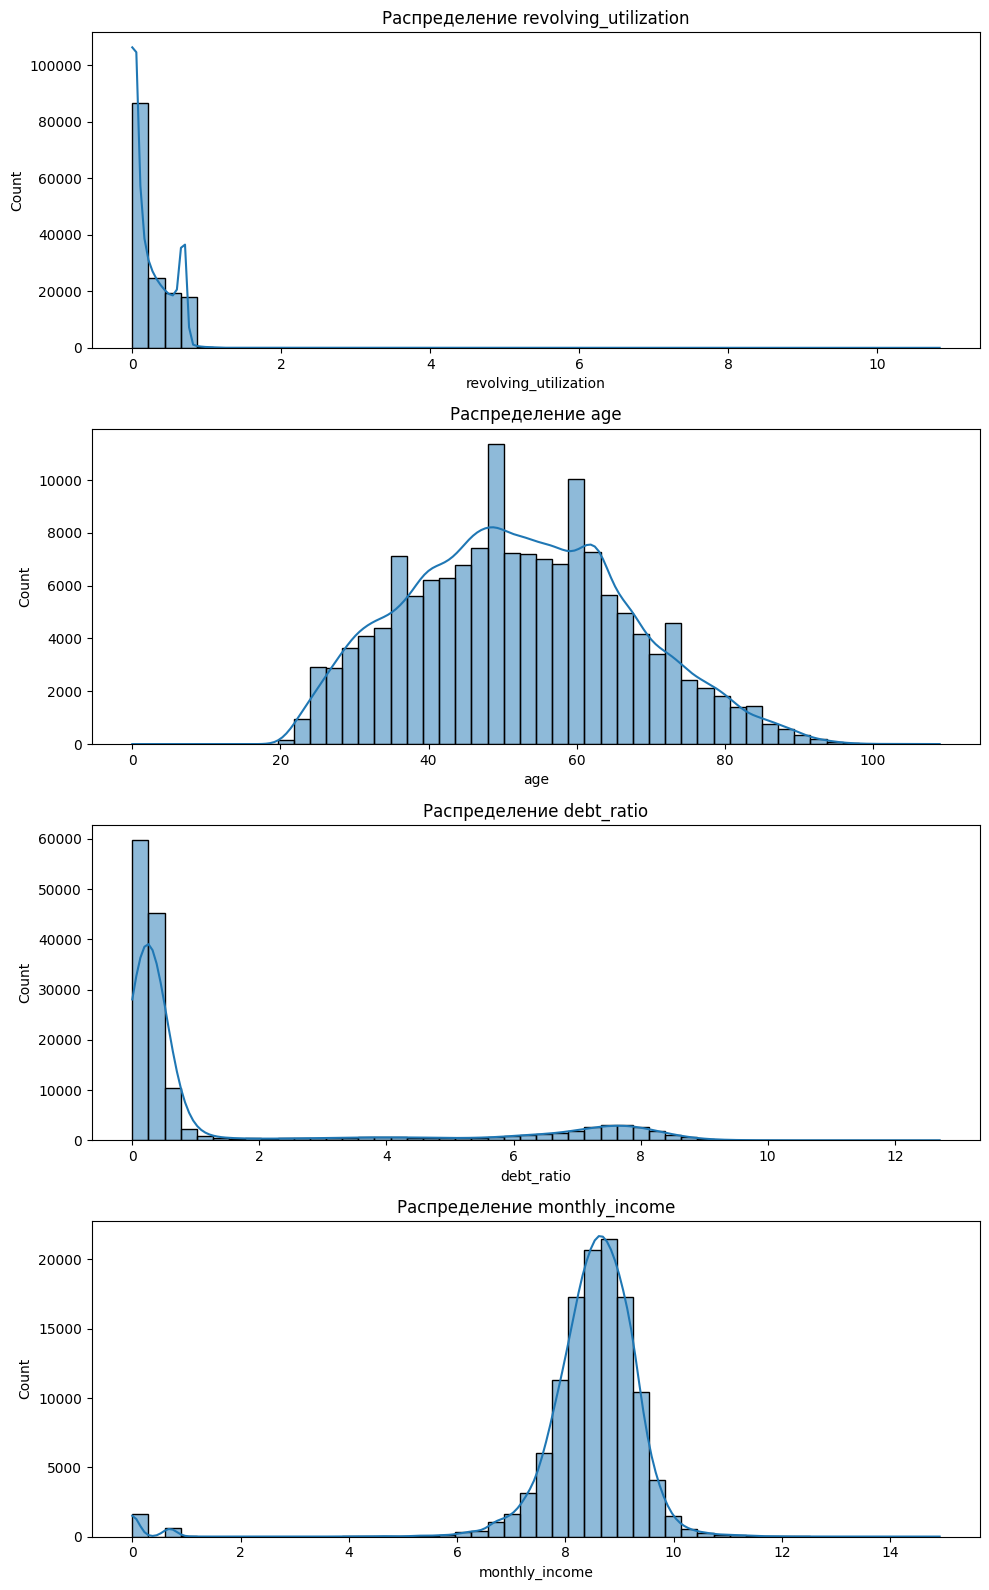

In [281]:
num_continuous_features = len(continuous_features)

plt.figure(figsize=(10, 16))
for i, column in enumerate(continuous_features):
    plt.subplot(num_continuous_features, 1, i + 1)
    if features_values_analysis.loc[column, "gamma1"] > 1:
        sns.histplot(np.log1p(data[column].dropna()), bins=50, kde=True)
    else:
        sns.histplot(data=data, x=column, bins=50, kde=True)
    plt.title(f"Распределение {column}")
    
plt.tight_layout()
plt.show()

**Вывод по блоку:**
1. Все признаки имеют ассиметричное распределение с тяжёлыми правыми хвостами;
2. Почти все признаки имеют серьёзные аномальные значения, сильно выбивающиеся из основного распределения;
3. В признаках `revolving_utilization`, `num_30_59_days_late`, `debt_ratio`, `num_open_credit_lines`, `num_90_days_late`, `num_real_estate_loans`, `num_60_89_days_late` аномальные значения, скорее всего являются ошибочными, требуется дополнительное рассмотрение;
4. Почти все выбросы из данных будут иметь негативное влияние на качество обучения, в том числе линейных моделей, которое приведёт к значительному снижению точности предсказания. Нужно будет продумать стратегии их обработки.

# Подробный анализ значений признаков (невозможные значения и выбросы)

## revolving utilization

**Обзор признака**

Признак `revolving utilization` показывает общий баланс по кредитным картам и кредитным линиям, кроме недвижимости и долгов в рассрочку.

Формула примерно следующая:

`суммарный долг по кредитным картам и личным кредитным линиям`
/
`суммарный лимит по этим кредитам и личным кредитным линиям`

Исходя из сути признака норма - это значения от `0` до `1`. Однако, как сейчас, так и в 2011 году была практика превышения кредитныйх лимитов, однако даже так, значения превышения можно представить до 5 раз, но не более. Все остальные значения нужно анализировать.

**Анализ значений признака**

Количественные характеристики признака

In [288]:
features_values_analysis.loc["revolving_utilization"]

count    149,391.0000
min            0.0000
1%             0.0000
5%             0.0000
10%            0.0032
25%            0.0301
mean           6.0711
std          250.2637
50%            0.1542
75%            0.5565
90%            0.9780
95%            1.0000
99%            1.0939
max       50,708.0000
gamma1        97.4332
gamma2    14,485.6753
Name: revolving_utilization, dtype: float64

Беглый осмотр экстремальных значений

In [298]:
data.query(f"revolving_utilization > {features_values_analysis.loc["revolving_utilization", "99%"]}").sample(20)

,target,revolving_utilization,age,num_30_59_days_late,debt_ratio,monthly_income,num_open_credit_lines,num_90_days_late,num_real_estate_loans,num_60_89_days_late,num_dependents
80221,0,1.2879,62,1,0.0621,"2,384.0000",2,0,0,2,0.0000
139424,1,1.2443,38,0,0.6727,"7,250.0000",15,0,4,0,2.0000
60473,0,1.0993,54,2,0.2475,"3,700.0000",4,0,1,0,3.0000
18117,1,2.4947,47,2,14.5780,"1,800.0000",10,0,0,0,0.0000
57926,1,1.2824,25,1,0.2211,"2,758.0000",4,2,0,1,2.0000
118982,1,1.1352,51,0,909.0000,NaN,7,0,1,1,0.0000
83052,0,"11,553.0000",66,1,"3,742.0000",NaN,6,0,1,0,2.0000
99617,1,1.1063,32,2,0.7633,"4,000.0000",6,0,1,0,1.0000
35534,1,1.2256,50,3,817.0000,NaN,12,3,0,0,0.0000
16972,0,1.2819,39,0,0.2942,"3,000.0000",6,0,0,1,2.0000


In [299]:
data.query(f"revolving_utilization > {features_values_analysis.loc["revolving_utilization", "99.5%"]}").sample(20)

,target,revolving_utilization,age,num_30_59_days_late,debt_ratio,monthly_income,num_open_credit_lines,num_90_days_late,num_real_estate_loans,num_60_89_days_late,num_dependents
11193,0,1.7841,26,2,0.1411,"2,812.0000",2,0,0,0,1.0000
32885,1,1.8683,51,2,"1,571.0000",NaN,2,1,1,0,0.0000
123581,0,"6,875.0000",55,0,0.1204,"33,333.0000",6,0,1,0,2.0000
104902,0,502.0000,28,0,0.2582,"2,083.0000",4,0,0,0,0.0000
100320,1,1.8363,35,2,0.0423,"3,050.0000",3,1,0,0,4.0000
131307,0,2.5231,33,0,0.2011,"5,811.0000",8,0,0,0,0.0000
134145,1,1.5509,51,2,0.2713,"6,974.0000",5,0,2,2,4.0000
110330,1,1.4684,50,3,0.4138,"3,365.0000",12,0,1,1,1.0000
50198,0,798.0000,62,0,"1,100.0000",NaN,4,0,1,0,0.0000
10460,0,"1,039.0000",65,0,0.1157,"8,400.0000",3,0,2,0,0.0000


Можно заметить, что зачастую огромные значения `revolving_utilization` часто сопровождается весьма небольшим значением `debt_ratio`. Это означает, что человек в десятки и тысячи раз превышает свой кредитный лимит, который установил ему банк, но при этом он тратит на обслужтивание кредитов часто даже не половину своего дохода.

Таким образом, это наталкивает на мысль, что значения, например, выше 2, скорее всего говорят о том, что лимит был установлен не верно, что и привело к аномальным значениям - ошибкам.

Посмотрим на распределение `debt_ratio` у экстремальных значений `revolving_utilization`. Правда при этом экстремальные значения `debt_ratio`, cвязанные с отсутствующим или низким `monthly_income` исключим.

In [307]:
num_samples_with_extreme_values_in_debt_ratio_and_monthly_income = (
    data
    .query(f"debt_ratio > {features_values_analysis.loc["debt_ratio", "99%"]}")
    .query(f"(monthly_income < {features_values_analysis.loc["monthly_income", "1%"]}) or (not monthly_income.notna())")    
).shape[0]
num_samples_with_extreme_values_in_debt_ratio_and_monthly_income

1410

In [310]:
(
    data
    .query(f"revolving_utilization > 2.0")
    .query(f"(monthly_income.notna()) or (monthly_income > {features_values_analysis.loc["monthly_income", "1%"]})")
    .describe(percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
    .T
).loc[
    ["debt_ratio", "monthly_income"],
    ["count", "min", "1%", "5%", "10%", "25%", "mean", "std", "50%", "75%", "90%", "95%", "99%", "max"]
]

,count,min,1%,5%,10%,25%,mean,std,50%,75%,90%,95%,99%,max
debt_ratio,278.0000,0.0008,0.0027,0.0205,0.0598,0.1515,20.6225,213.3877,0.2834,0.4700,0.8107,1.1522,158.8968,"2,597.0000"
monthly_income,278.0000,0.0000,31.0300,"1,624.6500","2,189.8000","4,000.0000","7,883.5252","6,419.8110","6,358.0000","10,000.0000","14,697.2000","18,617.5000","36,696.3200","44,472.0000"


Видно, что подавляющее большинство экстремальных значений `revolving_utilization` связано с `debt_ratio` не превышающим 1, а 75% вообще не превышающим даже 0.5. Таким образом, гипотеза о том, что экстремальные значения `revolving_utilization` (> 2.0) скорее связано с ошибками (неверный кридитный лимит (знаменатель, который и приводит к некорректным значениям дроби)).

Проверим ещё связь аномальных значений с целевой переменной.

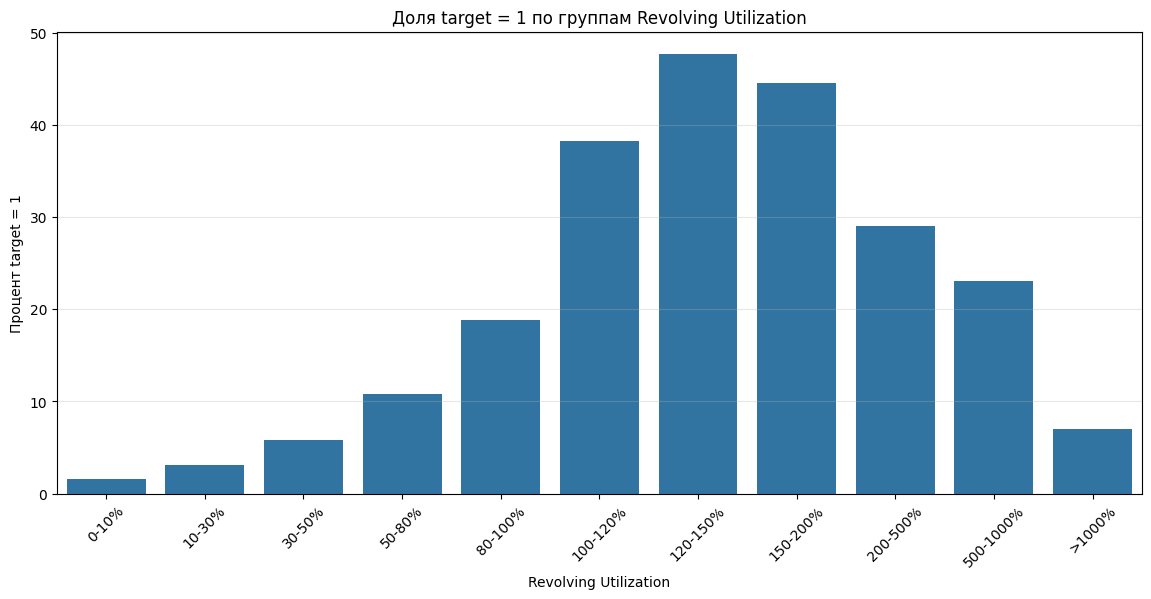

In [336]:
bins = [0, 0.1, 0.3, 0.5, 0.8, 1.0, 1.2, 1.5, 2.0, 5.0, 10.0, np.inf]
labels = ["0-10%", "10-30%", "30-50%", "50-80%", "80-100%", "100-120%", "120-150%", "150-200%", "200-500%", "500-1000%", ">1000%"]

temp = data.copy(deep=True)
temp["rev_util_bin"] = pd.cut(
    temp["revolving_utilization"],
    bins=bins,
    labels=labels,
    right=True
)

rev_util_summary = (
    temp
    .groupby("rev_util_bin", observed=True)
    .agg(
        count=("target", "size"),
        target_1_count=("target", "sum"),
        target_1_rate=("target", "mean")
    )
    .reset_index()
)

rev_util_summary["target_1_rate_pct"] = rev_util_summary["target_1_rate"] * 100

plt.figure(figsize=(14, 6))

sns.barplot(
    data=rev_util_summary,
    x="rev_util_bin",
    y="target_1_rate_pct"
)

plt.title("Доля target = 1 по группам Revolving Utilization")
plt.xlabel("Revolving Utilization")
plt.ylabel("Процент target = 1")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

**Вывод по значениям признака:**
1. Количество экстремальных, нереалистичных значений, у данного признака не велико, что наталкивает на мысль об ошибках;
2. Экстремальные значения > 1000% часто сопровождаются невысоким `debt_ratio`, что наталкивает на мысли о том, что лимиты были с ошибками, что и привело к аномалиям;
3. Огромные значения как правило не коррелируют с `target`, только умеренные, так что с оишбками можно поступать по разному.

Таким образом, в признаке нормальные значения, скорее всего, располагаются до 10, всё, что выше - это ошибки.

**Предполагаемая обработка признака:**

Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн.

1. добавить флаг об аномальности значения с порогом > 10;
2. выполнить клиппинг значений с порогом > 10;
3. выполнить логарифмирование признака для выравнивания масштаба значений признака.

In [338]:
data_dictionary

,column,description,types,role
0,target,У человека была просрочка 90 дней и более или более серьёзное нарушение платёжной дисциплины,binary,target
1,revolving_utilization,"Общий баланс по кредитным картам и личным кредитным линиям, кроме недвижимости и долгов в рассрочку, например автокредитов, делённый на сумму кредитных лимитов",percent,feature
2,age,Возраст заёмщика в годах,integer,feature
3,num_30_59_days_late,"Количество раз, когда заёмщик имел просрочку 30–59 дней, но не хуже, за последние 2 года",count,feature
4,debt_ratio,"Ежемесячные выплаты по долгам, алименты и расходы на проживание, делённые на ежемесячный валовый доход",percent,feature
5,monthly_income,Ежемесячный доход,float,feature
6,num_open_credit_lines,"Количество открытых кредитов, например автокредит или ипотека, и кредитных линий, например кредитных карт",count,feature
7,num_90_days_late,"Количество раз, когда заёмщик имел просрочку 90 дней или более",count,feature
8,num_real_estate_loans,"Количество ипотечных и других кредитов, связанных с недвижимостью, включая кредитные линии под залог жилья",count,feature
9,num_60_89_days_late,"Количество раз, когда заёмщик имел просрочку 60–89 дней, но не хуже, за последние 2 года",count,feature


## num_30_59_days_late / num_60_89_days_late / num_90_days_late

**Обзор признака**

Признак `num_30_59_days_late` (`60_89`/`90`) показывает, были ли у человека просрочки от `30` (`60` или `90`) до `59` (`89` или `неограничено`) дней.

Исходя из сути признака норма - это значения не сильно большие, думаю уж точно не больше 10, так как трудно представить, что кто-то будет выдавать много кредитов тому, кто и так уже имеет просрочки. Скорее всего, несколько просрочек может быть у человека, если ему выдали новый кредит на погашение старого или у него было несколько кредитов одновременно и он стал неплатёжеспособным, что и привело к нескольким просрочкам сразу.

**Анализ значений признака**

Количественные характеристики признаков

In [341]:
features_values_analysis.loc[["num_30_59_days_late", "num_60_89_days_late", "num_90_days_late"]]

,count,min,0.5%,1%,5%,10%,25%,mean,std,50%,75%,90%,95%,99%,99.5%,max,gamma1,gamma2
num_30_59_days_late,"149,391.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.3939,3.8530,0.0000,0.0000,1.0000,2.0000,4.0000,5.0000,98.0000,24.4746,616.2456
num_60_89_days_late,"149,391.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.2125,3.8105,0.0000,0.0000,0.0000,1.0000,2.0000,2.0000,98.0000,25.4244,649.0934
num_90_days_late,"149,391.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.2381,3.8262,0.0000,0.0000,0.0000,1.0000,3.0000,4.0000,98.0000,25.1074,637.8524


Беглый осмотр данных с аномальными значениями данных признаков

In [342]:
data.query(f"num_30_59_days_late > {features_values_analysis.loc["num_30_59_days_late", "99%"]}").sample(20)

,target,revolving_utilization,age,num_30_59_days_late,debt_ratio,monthly_income,num_open_credit_lines,num_90_days_late,num_real_estate_loans,num_60_89_days_late,num_dependents
105585,0,0.0004,58,6,"2,592.0000",NaN,10,0,2,2,0.0000
86166,1,1.0000,27,98,22.0000,NaN,0,98,0,98,NaN
43022,0,0.8725,61,5,"1,518.0000",NaN,13,0,2,0,0.0000
94106,1,1.0000,34,96,0.0000,"3,500.0000",0,96,0,96,1.0000
129774,0,0.8681,35,7,0.3459,"4,416.0000",14,0,2,3,1.0000
56073,0,0.4779,44,5,0.3259,"4,550.0000",9,0,1,0,2.0000
107706,1,0.9977,43,5,"2,752.0000",NaN,14,0,2,1,0.0000
87380,1,1.0000,43,5,0.5251,"3,004.0000",8,2,0,2,2.0000
3652,1,0.9914,40,6,0.8923,"5,200.0000",9,0,2,1,0.0000
15651,0,0.6393,47,6,0.3738,"5,580.0000",11,4,1,1,0.0000


In [343]:
data.query(f"num_30_59_days_late > {features_values_analysis.loc["num_30_59_days_late", "99.5%"]}").sample(20)

,target,revolving_utilization,age,num_30_59_days_late,debt_ratio,monthly_income,num_open_credit_lines,num_90_days_late,num_real_estate_loans,num_60_89_days_late,num_dependents
2286,0,1.0000,22,98,0.0000,NaN,0,98,0,98,0.0000
135629,0,0.7325,58,6,0.2328,"7,658.0000",9,1,1,0,0.0000
29325,1,1.0000,28,98,0.0337,"1,245.0000",0,98,0,98,0.0000
126269,1,1.0000,27,98,45.0000,NaN,0,98,0,98,0.0000
129224,1,1.0315,41,6,0.3168,"11,683.0000",4,0,1,1,1.0000
23915,1,1.0000,65,98,0.0122,"1,800.0000",0,98,0,98,0.0000
123225,0,0.2796,51,6,0.3253,"13,200.0000",12,0,2,0,2.0000
93111,1,0.9815,54,7,0.5068,"3,324.0000",10,0,1,0,1.0000
86166,1,1.0000,27,98,22.0000,NaN,0,98,0,98,NaN
77220,0,1.0000,25,98,0.0000,"1,958.0000",0,98,0,98,0.0000


Видно, что встречаются как весьма обычные значения, так и очень странные значения `96` и `98`. Причём эти значения стоят сразу в трёх признаках. Нужно проверить не какой-то ли это системный код.

Количество строк с num_30_59_days_late, num_60_89_days_late, num_90_days_late не равными одновременно 98

In [344]:
eq_values_for_features_days_late_98 =\
    data.query("num_30_59_days_late == 98 | num_60_89_days_late == 98 | num_90_days_late == 98")

num_not_all_days_late_eq_98 =\
    eq_values_for_features_days_late_98.shape[0]\
    -\
    eq_values_for_features_days_late_98.query("num_30_59_days_late == num_60_89_days_late == num_90_days_late == 98").shape[0]

In [345]:
num_not_all_days_late_eq_98

0

Количество строк с num_30_59_days_late, num_60_89_days_late, num_90_days_late не равными одновременно 96

In [346]:
eq_values_for_features_days_late_96 =\
    data.query("num_30_59_days_late == 96 | num_60_89_days_late == 96 | num_90_days_late == 96")

num_not_all_days_late_eq_96 =\
    eq_values_for_features_days_late_96.shape[0]\
    -\
    eq_values_for_features_days_late_96.query("num_30_59_days_late == num_60_89_days_late == num_90_days_late == 96").shape[0]

In [347]:
num_not_all_days_late_eq_96

0

Так как всегда значения `98` и `96` стоят во всех 3 признаках одновременно, то теория о том, что данные значения являются системными кодами выглядит весьма правдоподобной.

Теперь посмотрим на связь этих значений с `target`.

In [365]:
bins = [0, 1, 2, 4, 6, 10, 96, 98, 98.1]
labels = ["[0-1)", "[1-2)", "[2-4)", "[4-6)", "[6-10)", "[10-96)", "[96-98)", "[98, 98.1)"]

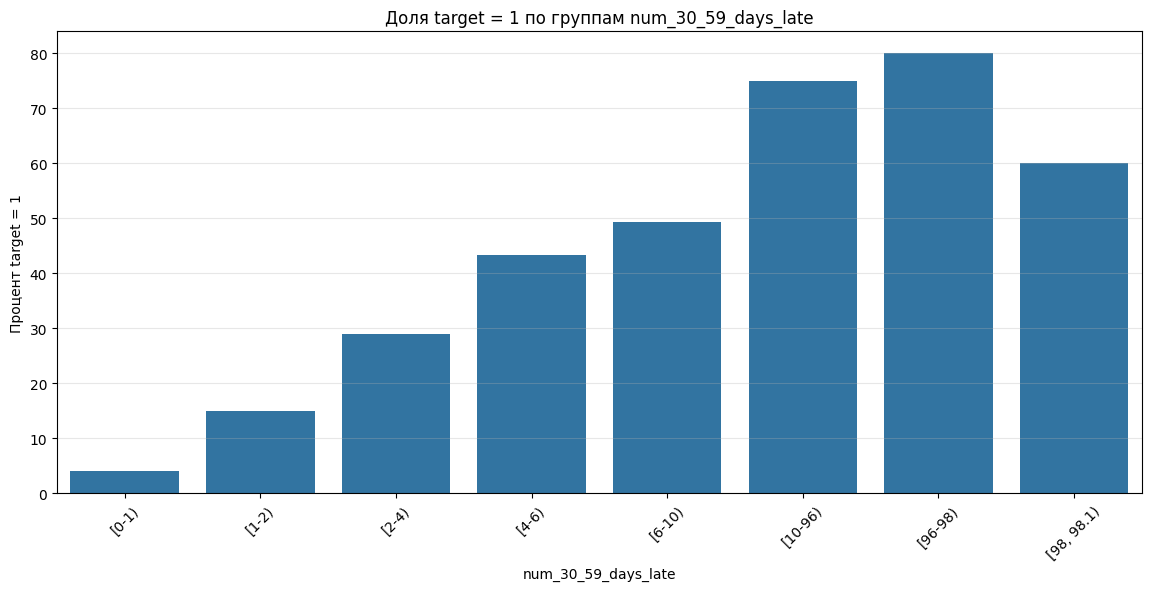

In [366]:
temp = data.copy(deep=True)
temp["num_30_59_days_late_bin"] = pd.cut(
    x=temp["num_30_59_days_late"],
    bins=bins,
    labels=labels,
    right=False
)

num_30_59_days_late_summary = (
    temp.groupby("num_30_59_days_late_bin")
    .agg(
        count=("target", "size"),
        target_1_count=("target", "sum"),
        target_1_rate=("target", "mean")
    )
    .reset_index()
)
num_30_59_days_late_summary["target_1_rate_pct"] = num_30_59_days_late_summary["target_1_rate"] * 100

plt.figure(figsize=(14, 6))

sns.barplot(
    data=num_30_59_days_late_summary,
    x="num_30_59_days_late_bin",
    y="target_1_rate_pct"
)

plt.title("Доля target = 1 по группам num_30_59_days_late")
plt.xlabel("num_30_59_days_late")
plt.ylabel("Процент target = 1")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

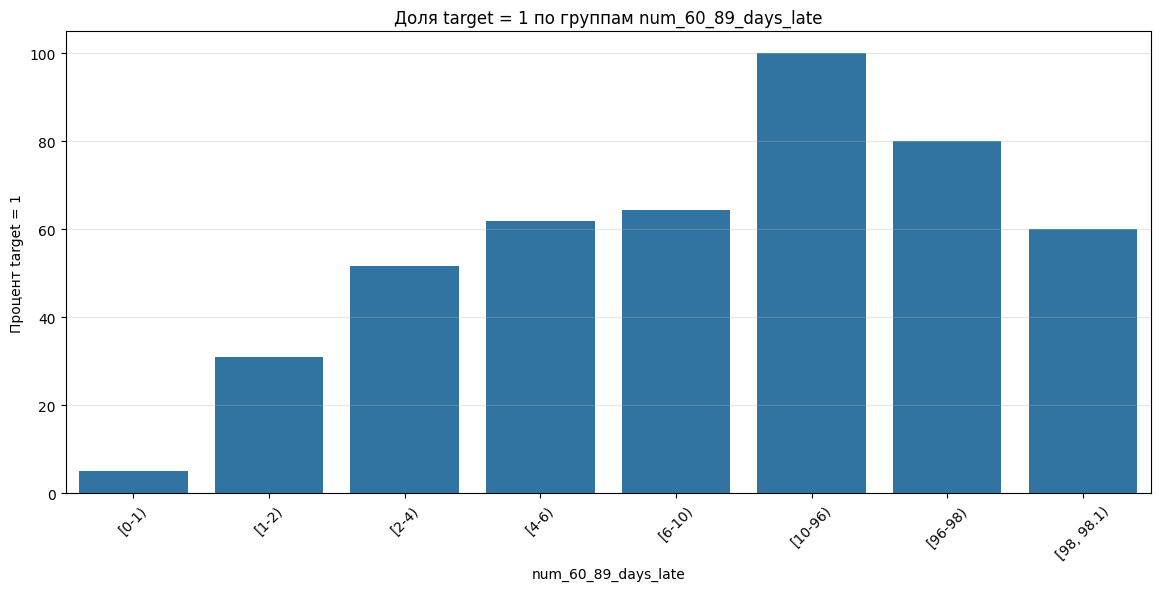

In [367]:
temp = data.copy(deep=True)
temp["num_60_89_days_late_bin"] = pd.cut(
    x=temp["num_60_89_days_late"],
    bins=bins,
    labels=labels,
    right=False
)

num_60_89_days_late_summary = (
    temp.groupby("num_60_89_days_late_bin")
    .agg(
        count=("target", "size"),
        target_1_count=("target", "sum"),
        target_1_rate=("target", "mean")
    )
    .reset_index()
)
num_60_89_days_late_summary["target_1_rate_pct"] = num_60_89_days_late_summary["target_1_rate"] * 100

plt.figure(figsize=(14, 6))

sns.barplot(
    data=num_60_89_days_late_summary,
    x="num_60_89_days_late_bin",
    y="target_1_rate_pct"
)

plt.title("Доля target = 1 по группам num_60_89_days_late")
plt.xlabel("num_60_89_days_late")
plt.ylabel("Процент target = 1")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

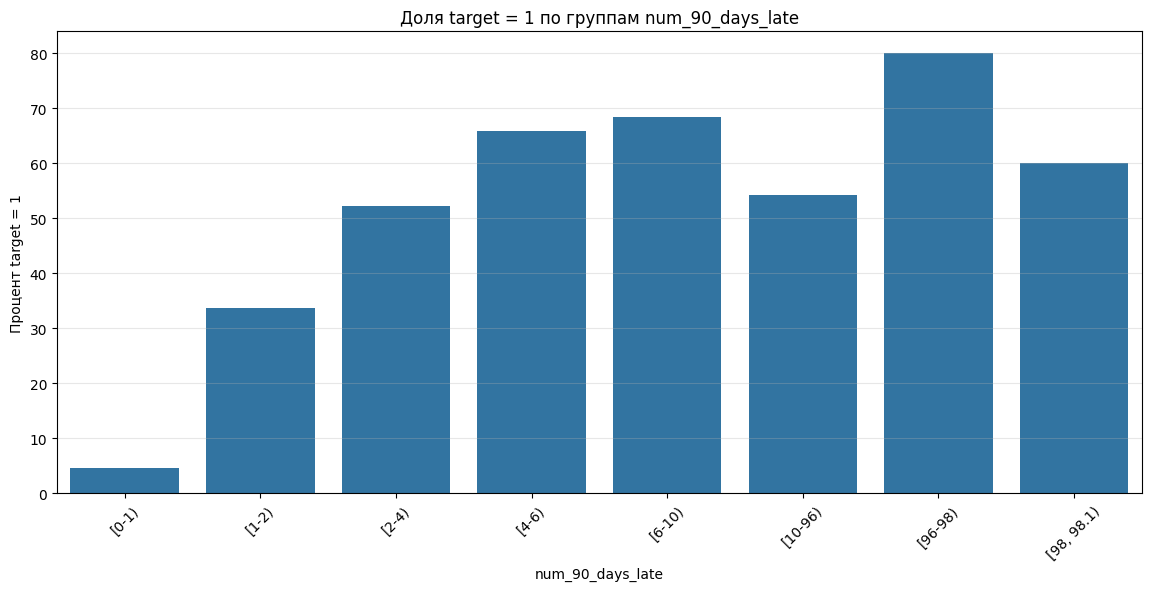

In [368]:
temp = data.copy(deep=True)
temp["num_90_days_late_bin"] = pd.cut(
    x=temp["num_90_days_late"],
    bins=bins,
    labels=labels,
    right=False    
)

num_90_days_late_summary = (
    temp.groupby("num_90_days_late_bin")
    .agg(
        count=("target", "size"),
        target_1_count=("target", "sum"),
        target_1_rate=("target", "mean")
    )
    .reset_index()
)
num_90_days_late_summary["target_1_rate_pct"] = num_90_days_late_summary["target_1_rate"] * 100

plt.figure(figsize=(14, 6))

sns.barplot(
    data=num_90_days_late_summary,
    x="num_90_days_late_bin",
    y="target_1_rate_pct"
)

plt.title("Доля target = 1 по группам num_90_days_late")
plt.xlabel("num_90_days_late")
plt.ylabel("Процент target = 1")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

Пожалуй можно сказать, что некоторая связь есть, процент тех, у кого были просрочки в следующие 2 года весьма высок, но он сопоставим с другими высокими значениями.

**Вывод по значениям признаков:**

В признаках `num_30_59_days_late`, `num_60_89_days_late`, `num_90_days_late` наблюдется одни и те же аномальные значения 96 или 98. Кроме того, данные значения встречаются синхронно во всех этих признаках. Всё это наталкивает на мысль о том, что данные значение являются системным кодом, который просочился в данные. Наталкивает на это опять же одновременность наступления и аномальность самих значений, которое в разы отличаются от ближайших значений.

**Предполагаемая обработка признаков:**

Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн.

1. добавить флаг о равенстве признаков 96 или 98;
2. значения 96 и 98 преобразуются в особые подобранные значения, которые не будут ломать распределения;
3. выполнить логарифмирование признаков для выравнивания масштаба значений признаков.

In [369]:
data_dictionary

,column,description,types,role
0,target,У человека была просрочка 90 дней и более или более серьёзное нарушение платёжной дисциплины,binary,target
1,revolving_utilization,"Общий баланс по кредитным картам и личным кредитным линиям, кроме недвижимости и долгов в рассрочку, например автокредитов, делённый на сумму кредитных лимитов",percent,feature
2,age,Возраст заёмщика в годах,integer,feature
3,num_30_59_days_late,"Количество раз, когда заёмщик имел просрочку 30–59 дней, но не хуже, за последние 2 года",count,feature
4,debt_ratio,"Ежемесячные выплаты по долгам, алименты и расходы на проживание, делённые на ежемесячный валовый доход",percent,feature
5,monthly_income,Ежемесячный доход,float,feature
6,num_open_credit_lines,"Количество открытых кредитов, например автокредит или ипотека, и кредитных линий, например кредитных карт",count,feature
7,num_90_days_late,"Количество раз, когда заёмщик имел просрочку 90 дней или более",count,feature
8,num_real_estate_loans,"Количество ипотечных и других кредитов, связанных с недвижимостью, включая кредитные линии под залог жилья",count,feature
9,num_60_89_days_late,"Количество раз, когда заёмщик имел просрочку 60–89 дней, но не хуже, за последние 2 года",count,feature


## debt ratio

**Обзор признака**

Признак `debt_ratio` означает отношение выплат по долгам (сюда входят ещё алименты и расходы на проживание) к ежемесячному валовому доходу.

Формула примерно такая:

`Сумма ежемесячных выплат по долгам` / `ежемесячный валовый доход`.

**Анализ значений признака**

Количественные характеристики признака

In [370]:
features_values_analysis.loc["debt_ratio"]

count    149,391.0000
min            0.0000
0.5%           0.0000
1%             0.0000
5%             0.0052
10%            0.0350
25%            0.1774
mean         354.4367
std        2,041.8435
50%            0.3682
75%            0.8753
90%        1,275.0000
95%        2,455.5000
99%        4,985.1000
99.5%      6,191.0500
max      329,664.0000
gamma1        94.9797
gamma2    13,681.5883
Name: debt_ratio, dtype: float64

Беглый осмотр данных с аномальными значениями признака

In [384]:
data.query("(debt_ratio > 1.0) and (debt_ratio < 3.0)").sample(20)

,target,revolving_utilization,age,num_30_59_days_late,debt_ratio,monthly_income,num_open_credit_lines,num_90_days_late,num_real_estate_loans,num_60_89_days_late,num_dependents
57826,0,0.4877,49,2,1.8892,"11,641.0000",9,0,2,0,2.0000
83392,0,0.5481,57,1,1.8389,"1,663.0000",11,0,2,0,0.0000
80721,0,0.0393,65,0,2.0484,"2,333.0000",6,0,3,0,0.0000
22947,0,0.7486,58,0,1.7445,"5,416.0000",8,0,3,0,0.0000
145513,0,0.8918,43,0,2.2848,"2,443.0000",10,7,2,0,2.0000
73610,0,0.9631,45,0,1.8328,"14,333.0000",9,0,3,0,0.0000
118943,0,0.9174,57,0,1.2287,"2,579.0000",15,0,2,0,0.0000
133767,0,0.5995,26,0,1.0719,820.0000,6,0,0,0,0.0000
44365,0,0.0281,41,0,1.2324,"4,086.0000",7,0,3,0,0.0000
108660,0,0.0523,65,1,1.2809,"4,000.0000",11,0,4,0,0.0000


In [377]:
data.query(f"debt_ratio > 3.0").sample(20)

,target,revolving_utilization,age,num_30_59_days_late,debt_ratio,monthly_income,num_open_credit_lines,num_90_days_late,num_real_estate_loans,num_60_89_days_late,num_dependents
42142,0,0.0000,63,0,"1,646.0000",0.0000,4,0,1,0,0.0000
122964,0,0.1073,43,0,7.1242,"1,650.0000",11,0,0,0,1.0000
6439,0,0.0489,25,0,"1,233.0000",NaN,5,0,1,0,0.0000
12804,0,0.0434,80,0,178.0000,NaN,4,0,0,0,0.0000
47128,0,0.0285,71,0,84.0000,NaN,6,0,0,0,0.0000
52444,0,0.2445,51,0,157.0000,NaN,5,0,0,0,1.0000
15654,0,0.0057,40,0,"1,950.0000",NaN,7,0,1,0,0.0000
32194,0,0.1016,64,0,"2,374.0000",NaN,7,0,1,0,1.0000
148872,0,0.8976,47,2,"20,351.0000",NaN,9,0,5,0,2.0000
57382,0,0.0828,77,0,55.0000,NaN,4,0,0,0,0.0000


Глядя на данные, можно сделать предположение, что нормальные данные лежат недалеко от `1`, а больше `3-4` это уже неадекватные значения, связанные с какими-то странными значениями в `monthly_income`. Проверим это.

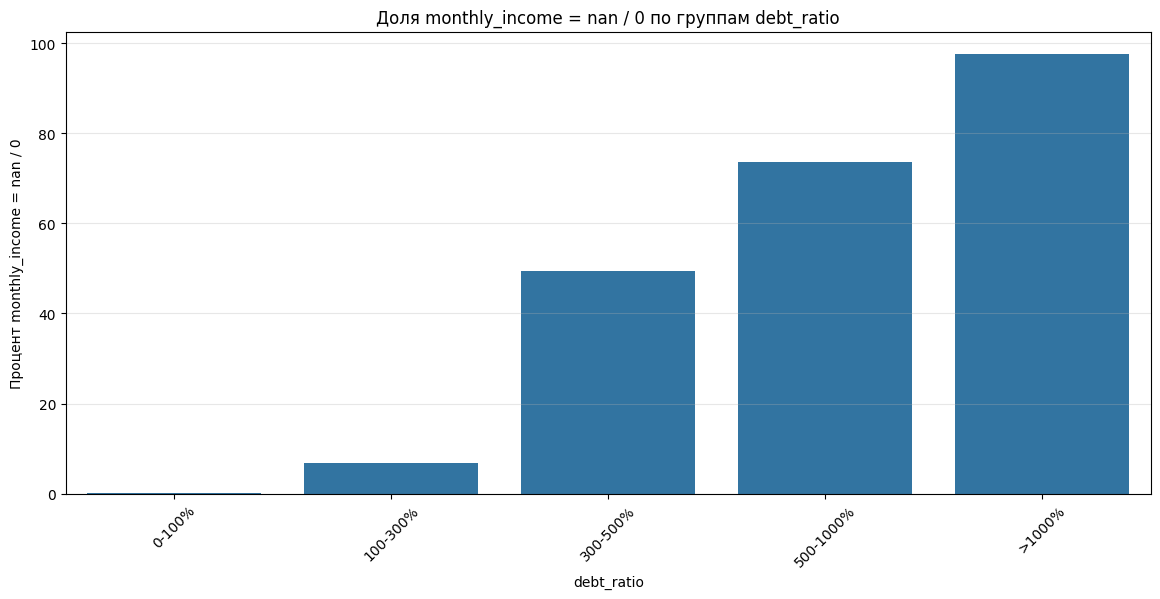

In [387]:
bins = [0, 1, 3, 5, 10, np.inf]
labels = ["0-100%", "100-300%", "300-500%", "500-1000%", ">1000%"]

temp = data.copy(deep=True)
temp["debt_ratio_bin"] = pd.cut(
    x=temp["debt_ratio"],
    bins=bins,
    labels=labels,
    right=True
)
temp["monthly_income_zero_or_nan"] = (temp["monthly_income"].fillna(0.0) == 0).astype(int)

debt_ratio_zero_and_nan_mon_inc_summary = (
    temp
    .groupby("debt_ratio_bin")
    .agg(
        count=("monthly_income", "size"),
        monthly_income_zero_or_nan_count=("monthly_income_zero_or_nan", "sum"),
        monthly_income_zero_or_nan_rate=("monthly_income_zero_or_nan", "mean")
    )
    .reset_index()
)
debt_ratio_zero_and_nan_mon_inc_summary["monthly_income_zero_or_nan_pct"] =\
    debt_ratio_zero_and_nan_mon_inc_summary["monthly_income_zero_or_nan_rate"] * 100

plt.figure(figsize=(14, 6))

sns.barplot(
    data=debt_ratio_zero_and_nan_mon_inc_summary,
    x="debt_ratio_bin",
    y="monthly_income_zero_or_nan_pct"
)

plt.title("Доля monthly_income = nan / 0 по группам debt_ratio")
plt.xlabel("debt_ratio")
plt.ylabel("Процент monthly_income = nan / 0")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

Процент экстремальных значений `debt_ratio` среди `monthly_income` == nan или 0.

In [393]:
temp = data.copy(deep=True)
temp = temp.query("(not monthly_income.notna()) or (monthly_income < 10e-6)")

temp.query("debt_ratio > 3.0").shape[0] / temp.shape[0] * 100

94.34769919252845

Ещё посмотрим как распределяются экстремальные значения среди `monthly_income` != nan или 0.

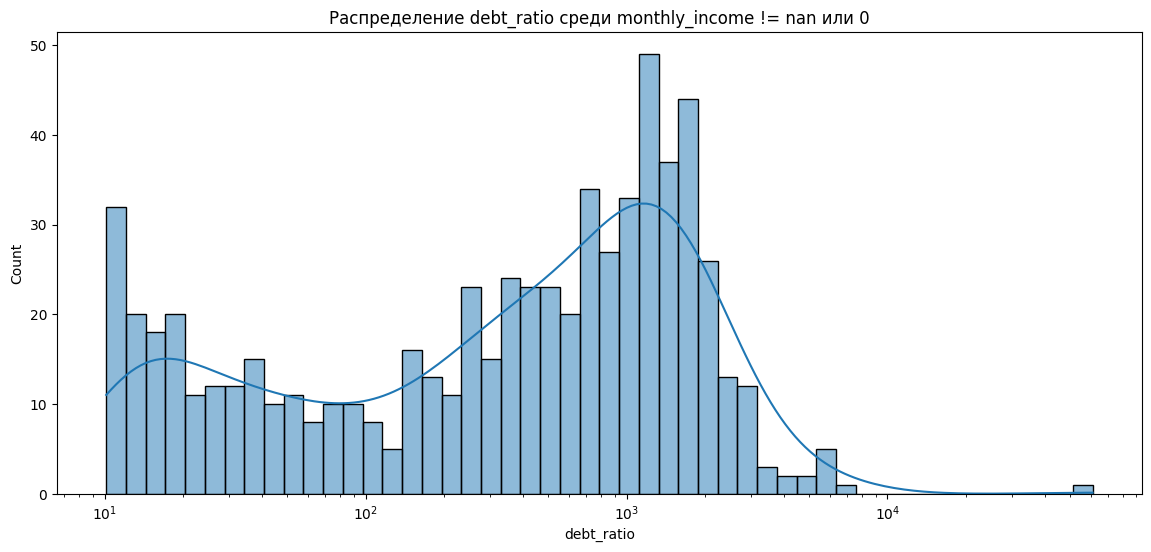

In [399]:
temp = data.copy(deep=True)
temp = temp.query("(monthly_income.notna()) and (monthly_income > 10e-6) and (debt_ratio > 10.0)")

plt.figure(figsize=(14, 6))
sns.histplot(data=temp, x="debt_ratio", bins=50, kde=True, log_scale=True)
plt.title("Распределение debt_ratio среди monthly_income != nan или 0")
plt.show()

In [401]:
temp = data.copy(deep=True)
temp = temp.query("(monthly_income.notna()) and (monthly_income > 10e-6)")

temp.query("debt_ratio > 10.0").shape[0] / temp.shape[0] * 100

0.5558648379641344

В целом можно сказать, что, как правило, аномальное значение `debt_ratio` является следствием низкого или отсутствующего `monthly_income`, за исключением единичных случаев.

В целом можно сказать, что аномальные значения - это скорее всего ошибки или случаи, когда человек получает неофицальных доход, например, ему дают деньги родители, которые он тратит на жильё, а официальных доход при это очень низкий.

Теперь проверим связь экстремальных значений с `target`.

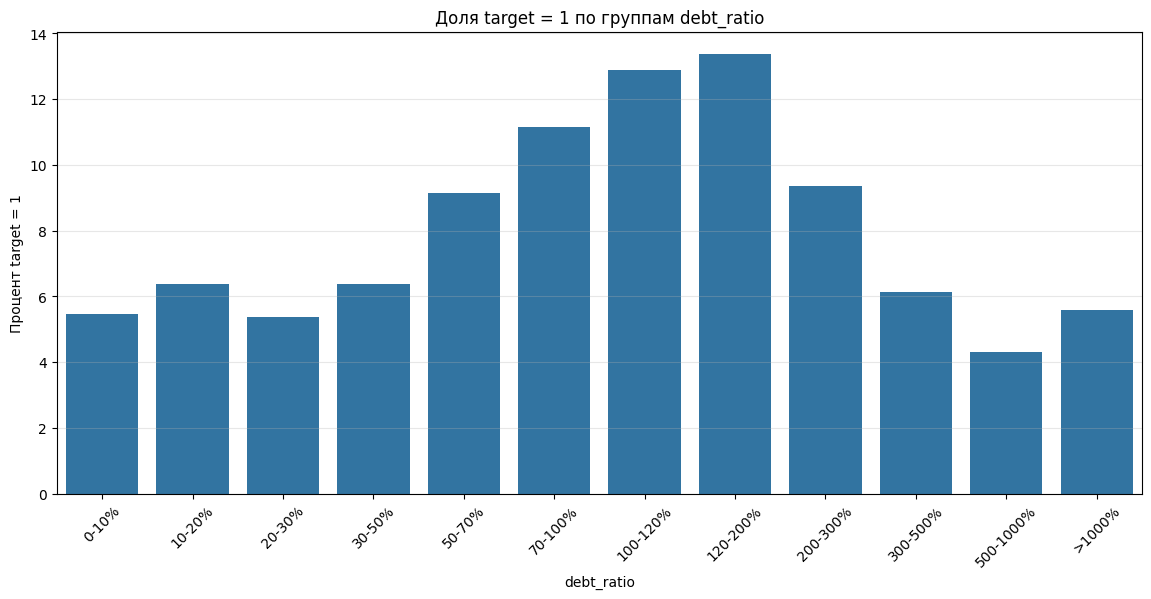

In [402]:
bins = [0.0, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 1.2, 2.0, 3.0, 5.0, 10.0, np.inf]
labels = ["0-10%", "10-20%", "20-30%", "30-50%", "50-70%", "70-100%", "100-120%", "120-200%", "200-300%", "300-500%", "500-1000%", ">1000%"]

temp = data.copy(deep=True)
temp["debt_ratio_bin"] = pd.cut(
    x=temp["debt_ratio"],
    bins=bins,
    labels=labels,
    right=True
)

debt_ratio_summary = (
    temp
    .groupby("debt_ratio_bin")
    .agg(
        count=("target", "size"),
        target_1_count=("target", "sum"),
        target_1_rate=("target", "mean")
    )
    .reset_index()
)
debt_ratio_summary["target_1_rate_pct"] = debt_ratio_summary["target_1_rate"] * 100

plt.figure(figsize=(14, 6))

sns.barplot(
    data=debt_ratio_summary,
    x="debt_ratio_bin",
    y="target_1_rate_pct"
)

plt.title("Доля target = 1 по группам debt_ratio")
plt.xlabel("debt_ratio")
plt.ylabel("Процент target = 1")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

В целом я бы сказал, что какой-то особенной связи между экстремальными значениями `debt_ratio` и `target` нет и выделять этого не стоит.

**Вывод по значениям признака:**

1. Во многом аномальные значения `debt_ratio` объясняются пропусками в значениях `monthly_income`;
2. Так как `debt_ratio` в числителе содержит ещё расходы на жильё и алименты, то выбросы могут ешё объясняться неофициальными доходами и тратами на жильё. Например, родители платят за жильё, а официальных доход этого не покрывает. Или например, есть траты по кредитке, а выплачивают его родители, а официального дохода нет;
3. В целом можно сказать, что ошибок +- нет, просто в случае аномальных значений можно сказать, что после какого-то порога и отсутствию `monthly_income` значение перестаёт быть информативным в количественном плане.

**Предполагаемая обработка признака:**

Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн.

1. добавить флаг об аномальности значения с порогом > 10;
2. выполнить клиппинг значений с порогом > 10;
3. выполнить логарифмирование признака для выравнивания масштаба значений признака;
4. добавить флаг об отсутствии `monthly_income` и наличии экстремальности `debt_ratio`.

## monthly income

**Обзор признака**

Признак `monthly_income` означает ежемесячный доход.

Поэтому, исходя из смысла признака, не может быть отрицательных значений и уж слишком астрономических.

**Анализ значений признака**

Количественные характеристики признака

In [404]:
features_values_analysis.loc["monthly_income"]

count      120,170.0000
min              0.0000
0.5%             0.0000
1%               0.0000
5%           1,300.0000
10%          2,029.0000
25%          3,400.0000
mean         6,675.0983
std         14,389.5822
50%          5,400.0000
75%          8,250.0000
90%         11,666.0000
95%         14,594.1000
99%         25,000.0000
99.5%       35,000.0000
max      3,008,750.0000
gamma1         114.0166
gamma2      19,493.9996
Name: monthly_income, dtype: float64

Беглый осмотр данных с аномальными значениями признака

In [405]:
data.query(f"monthly_income > {features_values_analysis.loc["monthly_income", "99%"]}").sample(20)

,target,revolving_utilization,age,num_30_59_days_late,debt_ratio,monthly_income,num_open_credit_lines,num_90_days_late,num_real_estate_loans,num_60_89_days_late,num_dependents
61614,0,0.3773,62,0,0.1788,"29,166.0000",6,0,2,0,0.0000
121355,0,0.8227,73,0,0.2338,"33,132.0000",11,0,3,0,0.0000
76899,0,0.1741,48,0,0.1308,"45,833.0000",9,0,3,0,3.0000
145855,0,0.0977,41,0,0.3163,"50,000.0000",12,0,7,0,2.0000
2554,0,0.3206,56,0,0.2607,"28,000.0000",26,0,2,0,2.0000
63012,0,0.2864,48,0,0.0984,"43,000.0000",13,0,2,0,5.0000
125619,0,0.0031,59,0,0.3113,"27,600.0000",9,0,2,0,0.0000
126838,0,0.2316,40,0,0.0031,"100,000.0000",3,0,0,0,0.0000
28979,0,0.8993,44,3,0.3440,"45,833.0000",15,0,3,0,3.0000
98123,0,0.5970,64,0,0.1478,"28,410.0000",10,0,1,0,0.0000


In [412]:
data.sort_values(by="monthly_income", na_position="first").tail(20)

,target,revolving_utilization,age,num_30_59_days_late,debt_ratio,monthly_income,num_open_credit_lines,num_90_days_late,num_real_estate_loans,num_60_89_days_late,num_dependents
17373,0,1.0000,34,1,0.0043,"251,608.0000",6,0,1,0,0.0000
23699,0,0.1964,57,1,0.0122,"261,666.0000",12,0,1,0,4.0000
43344,0,0.1514,59,0,0.0119,"287,662.0000",9,0,5,0,1.0000
106340,0,0.0065,45,0,0.1305,"304,000.0000",18,0,1,0,0.0000
88223,0,0.2815,51,0,0.1762,"324,000.0000",27,0,16,0,0.0000
88463,0,0.1761,44,0,0.0249,"408,333.0000",6,0,2,0,3.0000
124635,0,0.0360,43,0,0.0026,"428,250.0000",13,0,1,0,1.0000
114762,0,0.9469,44,2,0.0025,"440,000.0000",2,0,0,1,0.0000
137426,0,0.0798,61,0,0.0015,"562,466.0000",7,0,0,0,1.0000
35973,0,0.4397,64,0,0.0040,"582,369.0000",11,0,0,0,1.0000


В целом не видно каких-то подозрительных значений. Распределение, конечно, скошено, но это скорее вызвано наличием людей с выбросами, значения которых очень велики, но вполне могут быть.

Теперь посмотрим на распределение признаков у `monthly_income` == nan или 0.

In [413]:
temp = data.copy(deep=True)
temp = temp.query("(not monthly_income.notna()) or (monthly_income < 10e-6)")

temp = (
    temp
    .describe(percentiles=[0.005, 0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 0.995])
    .T
)[["count", "min", "0.5%", "1%", "5%", "10%", "25%", "mean", "std", "50%", "75%", "90%", "95%", "99%", "99.5%", "max"]]

temp

,count,min,0.5%,1%,5%,10%,25%,mean,std,50%,75%,90%,95%,99%,99.5%,max
target,"30,837.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0557,0.2294,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000
revolving_utilization,"30,837.0000",0.0000,0.0000,0.0000,0.0000,0.0005,0.0171,6.6302,216.5173,0.0828,0.4301,1.0000,1.0000,1.1139,1.4824,"22,198.0000"
age,"30,837.0000",21.0000,22.0000,24.0000,29.0000,35.0000,45.0000,55.9877,15.4599,57.0000,67.0000,76.0000,82.0000,89.0000,92.0000,109.0000
num_30_59_days_late,"30,837.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.4509,5.1325,0.0000,0.0000,1.0000,1.0000,3.0000,5.0000,98.0000
debt_ratio,"30,837.0000",0.0000,0.0000,0.0000,2.0000,15.0000,152.0000,"1,696.7234","4,215.9225","1,186.0000","2,399.0000","3,800.0000","4,930.0000","8,204.1200","10,475.5400","329,664.0000"
monthly_income,"1,616.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
num_open_credit_lines,"30,837.0000",0.0000,0.0000,0.0000,1.0000,2.0000,4.0000,7.3046,4.8225,6.0000,10.0000,14.0000,16.0000,23.0000,25.0000,45.0000
num_90_days_late,"30,837.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.3528,5.1241,0.0000,0.0000,0.0000,1.0000,3.0000,4.0000,98.0000
num_real_estate_loans,"30,837.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.8782,1.0310,1.0000,1.0000,2.0000,2.0000,4.0000,5.0000,23.0000
num_60_89_days_late,"30,837.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.3215,5.1130,0.0000,0.0000,0.0000,0.0000,2.0000,3.0000,98.0000


В целом, вроде, ничего необычного. Связь из признаков есть только с `debt_ratio`, но, как было уже предположено раньше, `monthly_income` является первопричиной экстремальных значений `debt_ratio`, а не наоборот.

Теперь посмотрим на связь nanов с target.

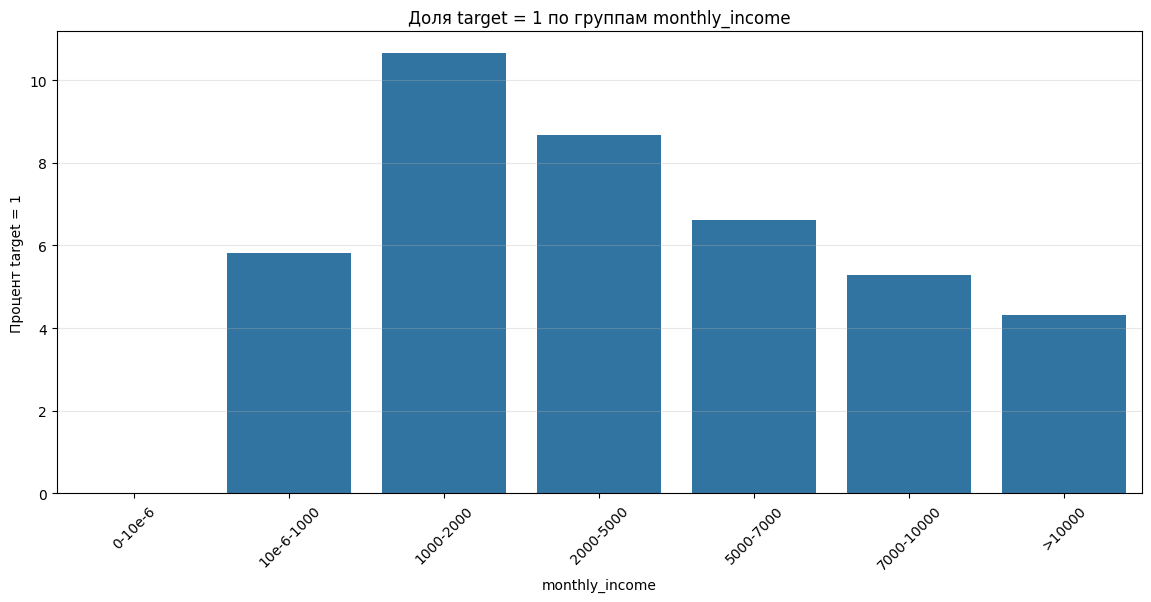

In [415]:
bins = [0, 10e-6, 1000, 2000, 5000, 7000, 10000, np.inf]
labels = ["0-10e-6", "10e-6-1000", "1000-2000", "2000-5000", "5000-7000", "7000-10000", ">10000"]

temp = data.copy(deep=True).fillna(0)
temp["monthly_income_bin"] = pd.cut(
    x=temp["monthly_income"],
    bins=bins,
    labels=labels,
    right=True
)

monthly_income_summary = (
    temp
    .groupby("monthly_income_bin")
    .agg(
        count=("target", "size"),
        target_1_count=("target", "sum"),
        target_1_rate=("target", "mean")
    )
    .reset_index()
)
monthly_income_summary["target_1_rate_pct"] = monthly_income_summary["target_1_rate"] * 100

plt.figure(figsize=(14, 6))

sns.barplot(
    data=monthly_income_summary,
    x="monthly_income_bin",
    y="target_1_rate_pct"
)

plt.title("Доля target = 1 по группам monthly_income")
plt.xlabel("monthly_income")
plt.ylabel("Процент target = 1")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

В целом есть связь, так как среди людей, у которых `monthly_income` == nan или 0, нет людей, которые допускали серьёзные просрочки в следующие 2 года.

**Вывод по значениям признака:**
1. В целом можно сказать, что в признаке нет ошибочных значений среди эксремальных значений;
2. В признаке явно есть выбросы - огромные значения, которые нужно как-то обработать;
3. В целом малые значения, кроме nan, почти не связаны с экстремальными значениями debt_ratio, поэтому нужно будет делать флаг не по малому monthly_income, а по большому debt_ratio.

**Предполагаемая обработка признака:**

Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн.

1. добавить флаг об аномальности значения с порогом по 99.75 процентилю;
2. выполнить клиппинг значений с порогом по 99.75 процентилю;
3. выполнить логарифмирование признака для выравнивания масштаба значений признака.

In [416]:
data_dictionary

,column,description,types,role
0,target,У человека была просрочка 90 дней и более или более серьёзное нарушение платёжной дисциплины,binary,target
1,revolving_utilization,"Общий баланс по кредитным картам и личным кредитным линиям, кроме недвижимости и долгов в рассрочку, например автокредитов, делённый на сумму кредитных лимитов",percent,feature
2,age,Возраст заёмщика в годах,integer,feature
3,num_30_59_days_late,"Количество раз, когда заёмщик имел просрочку 30–59 дней, но не хуже, за последние 2 года",count,feature
4,debt_ratio,"Ежемесячные выплаты по долгам, алименты и расходы на проживание, делённые на ежемесячный валовый доход",percent,feature
5,monthly_income,Ежемесячный доход,float,feature
6,num_open_credit_lines,"Количество открытых кредитов, например автокредит или ипотека, и кредитных линий, например кредитных карт",count,feature
7,num_90_days_late,"Количество раз, когда заёмщик имел просрочку 90 дней или более",count,feature
8,num_real_estate_loans,"Количество ипотечных и других кредитов, связанных с недвижимостью, включая кредитные линии под залог жилья",count,feature
9,num_60_89_days_late,"Количество раз, когда заёмщик имел просрочку 60–89 дней, но не хуже, за последние 2 года",count,feature


## num open credit lines

**Обзор признака**

Признак `num_open_credit_lines` означает количество открытых кредитов, например автокредит или ипотека, и кредитных линий, например, кредитных карт. То есть это просто общее количество кредитов и кредитных линий.

Исходя из смысла признака стоит ожидать небольшые значения, отрицательных юыть не может. В принципе и большие значения возможны, но, тогда это должны быть состоятельные клиенты, для которых банки готовы открыть много кредитных линий.

**Анализ значений признака**

Количественные характеристики признака

In [417]:
features_values_analysis.loc["num_open_credit_lines"]

count    149,391.0000
min            0.0000
0.5%           0.0000
1%             0.0000
5%             2.0000
10%            3.0000
25%            5.0000
mean           8.4809
std            5.1365
50%            8.0000
75%           11.0000
90%           15.0000
95%           18.0000
99%           24.0000
99.5%         27.0000
max           58.0000
gamma1         1.2218
gamma2         3.1173
Name: num_open_credit_lines, dtype: float64

Беглый осмотр данных с аномальными значениями признака

In [418]:
data.query(f"num_open_credit_lines > {features_values_analysis.loc["num_open_credit_lines", "99%"]}").sample(20)

,target,revolving_utilization,age,num_30_59_days_late,debt_ratio,monthly_income,num_open_credit_lines,num_90_days_late,num_real_estate_loans,num_60_89_days_late,num_dependents
18882,0,0.1926,63,0,0.3125,"12,500.0000",26,0,3,0,0.0000
135457,0,0.0000,53,0,0.4793,"9,000.0000",28,0,2,0,1.0000
38562,0,0.0182,62,0,0.0625,"3,200.0000",25,0,0,0,0.0000
21618,0,0.4232,45,1,0.9538,"3,200.0000",25,0,2,0,1.0000
89999,0,0.0073,59,0,"1,590.0000",0.0000,26,0,1,0,0.0000
109883,0,0.0000,56,0,"1,131.0000",NaN,29,0,2,0,0.0000
47446,0,0.1630,48,0,1.2175,"1,700.0000",29,0,0,0,0.0000
87532,0,0.1520,50,0,0.1176,"4,039.0000",32,0,0,0,0.0000
88301,0,0.7754,61,0,1.2114,"9,812.0000",33,0,3,0,1.0000
4513,0,0.1520,79,0,0.6703,"4,261.0000",28,0,2,0,0.0000


In [419]:
data.query(f"num_open_credit_lines > {features_values_analysis.loc["num_open_credit_lines", "99.5%"]}").sample(20)

,target,revolving_utilization,age,num_30_59_days_late,debt_ratio,monthly_income,num_open_credit_lines,num_90_days_late,num_real_estate_loans,num_60_89_days_late,num_dependents
60596,0,0.0931,62,0,0.2927,"11,960.0000",29,0,2,0,0.0000
63002,0,0.2545,54,0,0.3540,"9,000.0000",31,0,2,1,0.0000
31730,0,0.0045,66,0,0.4214,"2,500.0000",31,0,1,0,0.0000
56580,0,0.1090,44,0,0.5067,"13,380.0000",36,0,3,0,0.0000
55655,0,0.0094,63,0,0.7206,"4,000.0000",48,0,2,0,0.0000
25779,0,0.0034,61,0,1.4217,"2,721.0000",31,0,2,0,0.0000
2495,1,0.4514,48,0,2.5120,"12,080.0000",29,0,17,0,2.0000
42633,0,0.0284,47,1,0.2195,"9,270.0000",48,0,1,0,1.0000
46961,0,0.2794,32,1,0.4989,"5,547.0000",29,0,0,0,0.0000
22718,0,0.1307,55,0,0.2941,"9,925.0000",28,0,1,0,1.0000


В целом есть явно проблемные объекты: низкий или отсутствующий доход, высокий `debt_ratio` и большое число открытых кредитных линий. Это явно странно, а скорее всего неадекватно в принципе.

**Вывод по значениям признака:**

1. Пусть и есть выбросы, такие значения выглядят достаточно правдоподобно;
2. Ошибок в признаке нет;
3. Большого разброса по числам тут нет, хотя и по смыслу они есть. В принципе данный признак сам по себе является не плохим.

**Предполагаемая обработка признака:**

Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн.

1. добавить флаг об аномальности значения с порогом по 99.75 процентилю;
2. выполнить клиппинг значений с порогом по 99.75 процентилю;
3. выполнить логарифмирование признака для выравнивания масштаба значений признака.

## num real estate loans

Беглый осмотр данных с аномальными значениями в признаке

In [181]:
data.query(f"num_real_estate_loans > {feature_extreeme_values.loc["num_real_estate_loans", 0.9975]}").sample(40)

,target,revolving_utilization,age,num_30_59_days_late,debt_ratio,monthly_income,num_open_credit_lines,num_90_days_late,num_real_estate_loans,num_60_89_days_late,num_dependents
111622,0,0.0002,64,0,2.6433,"4,300.0000",21,0,8,0,0.0000
110397,0,0.1029,58,0,1.1667,"7,733.0000",24,0,9,0,1.0000
17779,0,0.0731,40,0,0.5100,"21,725.0000",18,0,8,0,2.0000
71291,0,0.4855,61,1,0.7251,"21,866.0000",34,0,9,0,0.0000
128696,0,0.0346,76,2,2.0543,"8,377.0000",27,0,15,0,1.0000
124867,0,0.1978,57,0,"18,230.0000",NaN,19,0,8,0,0.0000
98199,0,0.4843,43,1,0.9438,"10,900.0000",21,0,10,0,3.0000
140322,0,0.1961,37,0,0.9223,"8,900.0000",14,0,10,0,2.0000
138070,0,0.0062,63,0,"14,336.0000",NaN,19,0,9,0,0.0000
1476,0,1.0000,51,0,1.1232,"8,486.0000",11,0,9,0,1.0000


Распределение экстемальных значений признака

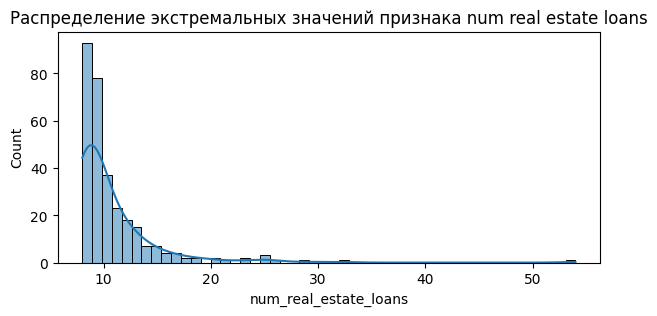

In [182]:
plt.figure(figsize=(7, 3))
sns.histplot(data=data.query(f"num_real_estate_loans > {feature_extreeme_values.loc["num_real_estate_loans", 0.9975]}"), x="num_real_estate_loans", bins=50, kde=True)
plt.title("Распределение экстремальных значений признака num real estate loans")
plt.show()

Распределение monthly_income в бинах num_real_estate_loans.

d:\Pet Projects\ML\give_me_some_credit\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
d:\Pet Projects\ML\give_me_some_credit\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


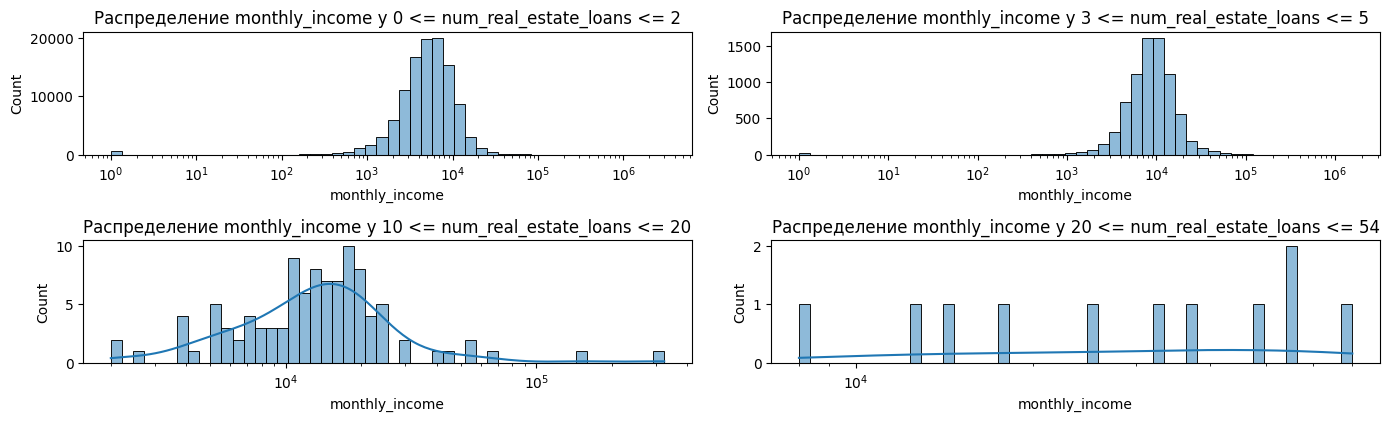

In [183]:
plt.figure(figsize=(14, 8))

for i, (left, right) in enumerate([(0, 2), (3, 5), (10, 20), (20, 54)]):
    temp = data.query(f"num_real_estate_loans >= {left} & num_real_estate_loans <= {right}")
    
    plt.subplot(4, 2, i+1)
    sns.histplot(data=temp, x="monthly_income", bins=50, kde=True, log_scale=True)
    plt.title(f"Распределение monthly_income у {left} <= num_real_estate_loans <= {right}")
    
plt.tight_layout()
plt.show()

Корреляция экстремальных значений признака с target = 1

In [184]:
corr_target_eq_1_with_num_real_estate_loans_extreme_value = dict()

for extreme_value in [7, 10, 13, 16, 20, 30, 40]:
    over_extreme_value = data.query(f"num_real_estate_loans > {extreme_value}")
    num_with_target_1 = over_extreme_value.query("target == 1").shape[0]
    all_num = over_extreme_value.shape[0]
    percent = num_with_target_1 / all_num * 100

    corr_target_eq_1_with_num_real_estate_loans_extreme_value[f">{extreme_value}"] = [num_with_target_1, all_num, percent]

corr_target_eq_1_with_num_real_estate_loans_extreme_value = pd.DataFrame(corr_target_eq_1_with_num_real_estate_loans_extreme_value, index=["with target = 1", "all", "percent"])

In [185]:
help["корреляция экстремальных значений num_real_estate_loans с target = 1"] =\
    "corr_target_eq_1_with_num_real_estate_loans_extreme_value"

In [186]:
corr_target_eq_1_with_num_real_estate_loans_extreme_value

,>7,>10,>13,>16,>20,>30,>40
with target = 1,63.0000,21.0000,8.0000,4.0000,2.0000,0.0000,0.0000
all,302.0000,94.0000,38.0000,20.0000,10.0000,2.0000,1.0000
percent,20.8609,22.3404,21.0526,20.0000,20.0000,0.0000,0.0000


**Вывод по значениям признака:**
1. В целом признак пусть и странноватый (не верится, что можно взять 5 и более кредитов под залог авто и дома), но значения в нём не выглядят ошибочными;
2. Выбросы, можно сказать, всё равно присутствуют, так как максимальное значение сильно отличается от среднего;
3. При проверке совметсного распределения monthly_income и num_real_estate_loans почти не обнаружено странностей типа малый monthly_income при высоком num_real_estate_loans, что ещё раз подтверждает гипотезу о том, что с данным признаком всё нормально.

**Предполагаемая обработка признака:**

Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн.

1. добавить флаг об аномальности значения с порогом по 99.75 процентилю;
2. выполнить клиппинг значений с порогом по 99.75 процентилю;
3. выполнить логарифмирование признака для выравнивания масштаба значений признака.

## num_dependents

Беглый осмотр данных с аномальными значениями в признаке

In [187]:
data.query(f"num_dependents > {feature_extreeme_values.loc["num_dependents", 0.9975]}").sample(40)

,target,revolving_utilization,age,num_30_59_days_late,debt_ratio,monthly_income,num_open_credit_lines,num_90_days_late,num_real_estate_loans,num_60_89_days_late,num_dependents
7148,0,0.6079,54,0,0.2550,"9,333.0000",6,0,1,0,6.0000
30598,0,0.2310,38,0,0.3174,"14,166.0000",9,0,2,0,8.0000
447,0,0.2437,48,0,0.1800,"8,900.0000",10,0,1,0,6.0000
93870,0,0.9886,48,0,"1,227.0000",NaN,4,0,1,0,8.0000
9095,0,0.2721,47,1,0.2612,"17,010.0000",15,0,1,0,6.0000
90768,1,0.9263,48,3,2.3759,"2,300.0000",14,0,2,1,6.0000
110579,0,0.1610,51,0,0.2537,"8,000.0000",10,0,2,0,7.0000
110648,0,0.3705,51,0,0.1717,"15,476.0000",16,0,0,0,6.0000
43805,0,0.3096,45,0,0.3186,"12,091.0000",13,0,1,0,6.0000
41138,0,0.0220,48,0,0.2271,"8,333.0000",5,0,1,0,6.0000


Распределение экстремальных значений признака

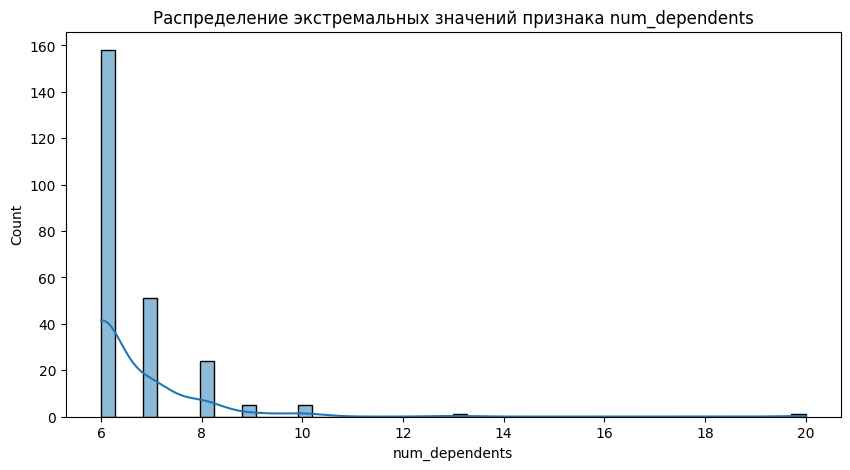

In [188]:
plt.figure(figsize=(10, 5))
sns.histplot(data=data.query(f"num_dependents > {feature_extreeme_values.loc["num_dependents", 0.9975]}"), x="num_dependents", bins=50, kde=True)
plt.title("Распределение экстремальных значений признака num_dependents")
plt.show()

Корреляция экстремальных значений в признаке с target = 1

In [189]:
corr_target_eq_1_with_num_dependents_extreme_value = dict()

for extreme_value in [4, 5, 6, 8, 10, 12]:
    over_extreme_value = data.query(f"num_dependents > {extreme_value}")
    num_with_target_1 = over_extreme_value.query("target == 1").shape[0]
    all_num = over_extreme_value.shape[0]
    percent = num_with_target_1 / all_num * 100

    corr_target_eq_1_with_num_dependents_extreme_value[f">{extreme_value}"] = [num_with_target_1, all_num, percent]

corr_target_eq_1_with_num_dependents_extreme_value = pd.DataFrame(corr_target_eq_1_with_num_dependents_extreme_value, index=["with target = 1", "all", "percent"])

In [190]:
help["корреляция экстремальных значений num_dependents с target = 1"] =\
    "corr_target_eq_1_with_num_dependents_extreme_value"

In [191]:
corr_target_eq_1_with_num_dependents_extreme_value

,>4,>5,>6,>8,>10,>12
with target = 1,99.0000,31.0000,7.0000,0.0000,0.0000,0.0000
all,991.0000,245.0000,87.0000,12.0000,2.0000,2.0000
percent,9.9899,12.6531,8.0460,0.0000,0.0000,0.0000


Анализ пропусков в признаке

In [192]:
data.query("num_dependents.notna() == False").sample(40)

,target,revolving_utilization,age,num_30_59_days_late,debt_ratio,monthly_income,num_open_credit_lines,num_90_days_late,num_real_estate_loans,num_60_89_days_late,num_dependents
59397,0,0.0928,40,0,"7,366.0000",NaN,7,0,5,0,NaN
8788,0,0.0000,72,0,"1,039.0000",NaN,10,0,1,0,NaN
18134,0,0.0056,37,1,"2,433.0000",NaN,14,0,1,0,NaN
65398,0,0.0405,77,0,12.0000,NaN,1,0,0,0,NaN
86411,0,1.0000,49,0,"3,762.0000",NaN,3,0,3,0,NaN
60649,0,0.7076,81,0,"1,440.0000",NaN,6,0,3,0,NaN
98855,0,0.0000,75,0,5.0000,NaN,9,0,0,0,NaN
125315,0,0.0504,57,0,35.0000,NaN,4,0,0,0,NaN
31791,0,0.0012,79,0,3.0000,NaN,3,0,0,0,NaN
34632,0,0.0730,48,0,"2,896.0000",NaN,7,0,2,0,NaN


Корреляция nanов в num_dependents с nanами в monthly_income

In [193]:
data_with_nan_in_num_dependents = data.query(f"num_dependents.notna() == False")
percent_nan_monthly_income_in_nan_num_dependents =\
    data_with_nan_in_num_dependents.shape[0] / data_with_nan_in_num_dependents.query("monthly_income.notna() == False").shape[0] * 100

In [194]:
help["Корреляция nanов в num_dependents с nanами в monthly_income"] =\
    percent_nan_monthly_income_in_nan_num_dependents

In [195]:
percent_nan_monthly_income_in_nan_num_dependents

100.0

**Вывод по значениям признака:**
1. В признаке есть выбросы;
2. Не похоже, что в признаке есть ошибки;
3. Пропуск в количестве иждевенцев совпадает с пропусками в monthly_income (обратное не верно).

**Предполагаемая обработка признака:**

Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн.

1. добавить флаг об аномальности значения с порогом по 99.75 процентилю;
2. выполнить клиппинг значений с порогом по 99.75 процентилю;
3. выполнить логарифмирование признака для выравнивания масштаба значений признака.

# Резюме анализа значений признаков

In [196]:
summary_features_values_analysis = pd.DataFrame({
    "feature": [
        "revolving_utilization",
        "age",
        "num_30_59_days_late, num_60_89_days_late, num_90_days_late",
        "debt_ratio",
        "monthly_income",
        "num_open_credit_lines",
        "num_real_estate_loans",
        "num_dependents"
    ],
    "наличие пропусков": [
        "нет",
        "нет",
        "нет",
        "нет",
        "да",
        "нет",
        "нет",
        "да"
    ],
    "объяснение пропусков и корреляция с target = 1": [
        "-",
        "-",
        "-",
        "-",
        "просто пропуски и всё; отрицательная, но до конца не ясно",
        "-",
        "-",
        "просто пропуски и всё; -"
    ],
    "наличие экстремальных значений": [
        "да",
        "нет",
        "да - 96 и 98",
        "да",
        "да",
        "да",
        "да",
        "да"

    ],
    "причины появления экстремальных значений": [
        "вероятнее всего это ошибки либо системы, либо записей",
        "-",
        "системные коды, которые просочились в данные",
        "скорее всего они связаны с отсутствием или низкими значениями monthly_income, что и повлияло на аномально большие значения признака",
        "просто особенные представители, ошибок нет",
        "просто особенные представители, ошибок нет",
        "просто особенные представители, ошибок нет",
        "просто особенные представители, ошибок нет"
    ],
    "корреляция экстремальных значений с target = 1": [
        "отрицательная, что наталкивает дополнительно на мысли об ошибках",
        "-",
        "-",
        "скорее отрицательная, но до конца не понятно",
        "отрицательная, но до конца не понятно",
        "не ясно",
        "не ясно",
        "отрицательная, но до конца не понятно"
    ],
    "предполагаемая обработка признака": [
        "Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн.\n\n1. добавить флаг об аномальности значения с порогом по 99.75 процентилю;\n2. выполнить клиппинг значений с порогом по 99.75 процентилю;\n3. выполнить логарифмирование признака для выравнивания масштаба значений признака.",
        "-",
        "Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн.\n\n1. добавить флаг о равенстве признаков 96 или 98;\n2. значения 96 и 98 преобразуются в особые подобранные значения, которые не будут ломать распределения;\n3. выполнить логарифмирование признаков для выравнивания масштаба значений признаков.",
        "Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн.\n\n1. добавить флаг об аномальности значения с порогом по 90 процентилю;\n2. выполнить клиппинг значений с порогом по 90 процентилю;\n3. выполнить логарифмирование признака для выравнивания масштаба значений признака.",
        "Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн.\n\n1. добавить флаг об аномальности значения с порогом по 99.75 процентилю;\n2. выполнить клиппинг значений с порогом по 99.75 процентилю;\n3. выполнить логарифмирование признака для выравнивания масштаба значений признака.",
        "Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн.\n\n1. добавить флаг об аномальности значения с порогом по 99.75 процентилю;\n2. выполнить клиппинг значений с порогом по 99.75 процентилю;\n3. выполнить логарифмирование признака для выравнивания масштаба значений признака.",
        "Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн.\n\n1. добавить флаг об аномальности значения с порогом по 99.75 процентилю;\n2. выполнить клиппинг значений с порогом по 99.75 процентилю;\n3. выполнить логарифмирование признака для выравнивания масштаба значений признака.",
        "Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн.\n\n1. добавить флаг об аномальности значения с порогом по 99.75 процентилю;\n2. выполнить клиппинг значений с порогом по 99.75 процентилю;\n3. выполнить логарифмирование признака для выравнивания масштаба значений признака."
    ]
})

In [197]:
summary_features_values_analysis.style.set_properties(**{
    "text-align": "left",
    "white-space": "pre-wrap"
})

,feature,наличие пропусков,объяснение пропусков и корреляция с target = 1,наличие экстремальных значений,причины появления экстремальных значений,корреляция экстремальных значений с target = 1,предполагаемая обработка признака
0,revolving_utilization,нет,-,да,"вероятнее всего это ошибки либо системы, либо записей","отрицательная, что наталкивает дополнительно на мысли об ошибках","Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн. 1. добавить флаг об аномальности значения с порогом по 99.75 процентилю; 2. выполнить клиппинг значений с порогом по 99.75 процентилю; 3. выполнить логарифмирование признака для выравнивания масштаба значений признака."
1,age,нет,-,нет,-,-,-
2,"num_30_59_days_late, num_60_89_days_late, num_90_days_late",нет,-,да - 96 и 98,"системные коды, которые просочились в данные",-,"Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн. 1. добавить флаг о равенстве признаков 96 или 98; 2. значения 96 и 98 преобразуются в особые подобранные значения, которые не будут ломать распределения; 3. выполнить логарифмирование признаков для выравнивания масштаба значений признаков."
3,debt_ratio,нет,-,да,"скорее всего они связаны с отсутствием или низкими значениями monthly_income, что и повлияло на аномально большие значения признака","скорее отрицательная, но до конца не понятно","Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн. 1. добавить флаг об аномальности значения с порогом по 90 процентилю; 2. выполнить клиппинг значений с порогом по 90 процентилю; 3. выполнить логарифмирование признака для выравнивания масштаба значений признака."
4,monthly_income,да,"просто пропуски и всё; отрицательная, но до конца не ясно",да,"просто особенные представители, ошибок нет","отрицательная, но до конца не понятно","Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн. 1. добавить флаг об аномальности значения с порогом по 99.75 процентилю; 2. выполнить клиппинг значений с порогом по 99.75 процентилю; 3. выполнить логарифмирование признака для выравнивания масштаба значений признака."
5,num_open_credit_lines,нет,-,да,"просто особенные представители, ошибок нет",не ясно,"Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн. 1. добавить флаг об аномальности значения с порогом по 99.75 процентилю; 2. выполнить клиппинг значений с порогом по 99.75 процентилю; 3. выполнить логарифмирование признака для выравнивания масштаба значений признака."
6,num_real_estate_loans,нет,-,да,"просто особенные представители, ошибок нет",не ясно,"Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн. 1. добавить флаг об аномальности значения с порогом по 99.75 процентилю; 2. выполнить клиппинг значений с порогом по 99.75 процентилю; 3. выполнить логарифмирование признака для выравнивания масштаба значений признака."
7,num_dependents,да,просто пропуски и всё; -,да,"просто особенные представители, ошибок нет","отрицательная, но до конца не понятно","Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн. 1. добавить флаг об аномальности значения с порогом по 99.75 процентилю; 2. выполнить клиппинг значений с порогом по 99.75 процентилю; 3. выполнить логарифмирование признака для выравнивания масштаба значений признака."


In [198]:
help["Резюме анализа значений признаков"] = "summary_features_values_analysis"

# Анализ зависимости признаков